In [2]:
!pip install rapidfuzz

import os
import re
import numpy as np
import pandas as pd
from functools import reduce
from google.colab import drive
from rapidfuzz import process, fuzz
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

drive.mount('/content/drive')

MASTER_PATH = '/content/drive/MyDrive/ARSEN/Daftar_Kabupaten_Kota_Indonesia_2026.xlsx'
DATA_FOLDERS = [
    '/content/drive/MyDrive/ARSEN/semua_data',
    '/content/drive/MyDrive/ARSEN/Harga Pangan Berdasarkan Komoditas',
]
OUTPUT_FOLDER = '/content/drive/MyDrive/ARSEN/hasil_standarisasi'
ZONAL_PATH = os.path.join(OUTPUT_FOLDER, 'zonal_stats_hasil.csv')
TAHUN_REFERENSI = 2024
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

master = pd.read_excel(MASTER_PATH)
master.columns = [c.strip() for c in master.columns]

master.loc[master['Nama Daerah'] == 'Pasangkayu', 'Jenis'] = 'KABUPATEN'
tambahan_wilayah = pd.DataFrame([
    {'Provinsi': 'Sumatera Utara', 'Nama Daerah': 'Sibolga', 'Jenis': 'KOTA'},
    {'Provinsi': 'Sulawesi Selatan', 'Nama Daerah': 'Sidenreng Rappang', 'Jenis': 'KABUPATEN'},
    {'Provinsi': 'Sulawesi Tenggara', 'Nama Daerah': 'Baubau', 'Jenis': 'KOTA'},
    {'Provinsi': 'Gorontalo', 'Nama Daerah': 'Pohuwato', 'Jenis': 'KABUPATEN'},
])
master = pd.concat([master, tambahan_wilayah], ignore_index=True)

master['nama_gabungan'] = master['Jenis'].str.title() + ' ' + master['Nama Daerah']
master_lookup = master['nama_gabungan'].tolist()
provinsi_master_list = master['Provinsi'].dropna().unique().tolist()

def compact(s):
    return re.sub(r'\s+', '', re.sub(r'^(Kabupaten|Kota)\s*', '', s, flags=re.IGNORECASE)).lower()

master_compact_map = {}
for m in master_lookup:
    master_compact_map.setdefault(compact(m), []).append(m)

PROVINSI_ALIAS_MAP = {
    'DKI JAKARTA': 'JAKARTA', 'DAERAH KHUSUS IBUKOTA JAKARTA': 'JAKARTA', 'JAKARTA RAYA': 'JAKARTA',
    'DI YOGYAKARTA': 'YOGYAKARTA', 'D I YOGYAKARTA': 'YOGYAKARTA', 'DAERAH ISTIMEWA YOGYAKARTA': 'YOGYAKARTA',
    'KEPULAUAN BANGKA BELITUNG': 'BANGKA BELITUNG', 'BANGKA BELITUNG': 'BANGKA BELITUNG',
    'KEPULAUAN RIAU': 'KEPULAUAN RIAU',
    'NTB': 'NUSA TENGGARA BARAT', 'NTT': 'NUSA TENGGARA TIMUR',
}

def normalize_provinsi(s):
    s = str(s).upper().strip()
    s = re.sub(r'^PROVINSI\s+', '', s)
    s = re.sub(r'^PROV\.?\s+', '', s)
    s = re.sub(r'\bKEP\.', 'KEPULAUAN', s)
    s = re.sub(r'\bKEP\b', 'KEPULAUAN', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return PROVINSI_ALIAS_MAP.get(s, s)

provinsi_norm_map = {}
for p in provinsi_master_list:
    provinsi_norm_map[normalize_provinsi(p)] = p
provinsi_norm_keys = list(provinsi_norm_map.keys())

KOREKSI_MANUAL = {
    'Kota Baru': 'Kabupaten Kotabaru',
    'Kota Sampit': 'Kabupaten Kotawaringin Timur',
    'Kota Tanjung': 'Kabupaten Tabalong',
    'Kota Watampone': 'Kabupaten Bone',
    'Kota Singaraja': 'Kabupaten Buleleng',
    'Kota Tanjung Pandan': 'Kabupaten Belitung',
    'Kota Tembilahan': 'Kabupaten Indragiri Hilir',
    'Kota Meulaboh': 'Kabupaten Aceh Barat',
    'Kota Maumere': 'Kabupaten Sikka',
    'Kota Padang Sidempuan': 'Kota Padangsidimpuan',
    'Kota Surakarta (Solo)': 'Kota Surakarta',
    'Kota Baubau': 'Kota Baubau',
    'Kota Sibolga': 'Kota Sibolga',
    'Kabupaten Toba': 'Kabupaten Toba Samosir',
    'Siau Tagulandang Biaro': 'Kabupaten Kepulauan Siau Tagulandang Biaro',
    'Sidenreng Rappang': 'Kabupaten Sidenreng Rappang',
    'Pohuwato': 'Kabupaten Pohuwato',
    'Pasangkayu': 'Kabupaten Pasangkayu',
    'Mamuju Utara': 'Kabupaten Pasangkayu',
}

BUANG = {'Semua Provinsi', 'PROVINSI / KABUPATEN', 'RPMJD'}
PROVINSI_NYASAR = {'D.I. Yogyakarta'}
STOPWORDS_NON_WILAYAH_UPPER = {'INDONESIA', 'TOTAL', 'JUMLAH', 'RATA-RATA', 'RATA RATA', 'NASIONAL', 'GRAND TOTAL', '-'}
CATATAN_PREFIX = ('CATATAN', 'SUMBER', 'KETERANGAN', 'NOTE', 'SOURCE')

def is_angka(x):
    try:
        float(str(x).replace('.', '', 1).replace(',', ''))
        return True
    except ValueError:
        return False

def clean_name(name):
    name = str(name).strip()
    name = re.sub(r'\s+', ' ', name)
    name = re.sub(r'^Kab\.\s*', 'Kabupaten ', name, flags=re.IGNORECASE)
    name = re.sub(r'^Kab\s+', 'Kabupaten ', name, flags=re.IGNORECASE)
    name = re.sub(r'^Kota\s+Adm\.?\s*', 'Kota ', name, flags=re.IGNORECASE)
    return name.strip()

def cek_trivial(teks_asli):
    teks = str(teks_asli).strip()
    if teks == '' or teks.lower() == 'nan':
        return 'kosong'
    if is_angka(teks):
        return 'bukan_teks_kode'
    if teks in BUANG:
        return 'level_nasional'
    if teks in PROVINSI_NYASAR:
        return 'level_provinsi'
    upper = teks.upper().strip()
    if upper in STOPWORDS_NON_WILAYAH_UPPER or upper.startswith(CATATAN_PREFIX):
        return 'level_nasional'
    return None

_provinsi_raw_cache = {}

def match_provinsi_raw(nama_asli):
    if nama_asli in _provinsi_raw_cache:
        return _provinsi_raw_cache[nama_asli]
    norm = normalize_provinsi(nama_asli)
    if norm in provinsi_norm_map:
        hasil = (provinsi_norm_map[norm], 100, 'exact')
    else:
        fz = process.extractOne(norm, provinsi_norm_keys, scorer=fuzz.token_sort_ratio)
        hasil = (provinsi_norm_map[fz[0]], fz[1], 'fuzzy') if fz else (None, 0, 'fuzzy')
    _provinsi_raw_cache[nama_asli] = hasil
    return hasil

def match_provinsi(nama_asli, threshold=85):
    trivial = cek_trivial(nama_asli)
    if trivial is not None:
        return (None, 0, trivial)
    nama, skor, cara = match_provinsi_raw(nama_asli)
    if cara == 'exact':
        return (nama, skor, 'exact_provinsi')
    status = 'fuzzy_ok_provinsi' if skor >= threshold else 'cek_manual'
    return (nama, skor, status)

RECOGNIZED_STATUS_PROVINSI = {'exact_provinsi', 'fuzzy_ok_provinsi'}
_kk_raw_cache = {}

def match_kabkota_raw(nama_asli):
    if nama_asli in KOREKSI_MANUAL:
        return (KOREKSI_MANUAL[nama_asli], 100, 'exact')
    if nama_asli in _kk_raw_cache:
        return _kk_raw_cache[nama_asli]

    nama_bersih = clean_name(nama_asli)
    sudah_ada_prefix = bool(re.match(r'^(Kabupaten|Kota)\s', nama_bersih, flags=re.IGNORECASE))
    kandidat_coba = [nama_bersih]
    if not sudah_ada_prefix:
        kandidat_coba.insert(0, f'Kabupaten {nama_bersih}')

    for coba in kandidat_coba:
        if coba in master_lookup:
            hasil = (coba, 100, 'exact')
            _kk_raw_cache[nama_asli] = hasil
            return hasil
        kandidat_compact = master_compact_map.get(compact(coba), [])
        if len(kandidat_compact) == 1:
            hasil = (kandidat_compact[0], 97, 'compact_match')
            _kk_raw_cache[nama_asli] = hasil
            return hasil

    nama_tanpa_jenis = re.sub(r'^(Kabupaten|Kota)\s+', '', nama_bersih, flags=re.IGNORECASE)
    kandidat = [m for m in master_lookup if nama_tanpa_jenis.lower() == re.sub(r'^(Kabupaten|Kota)\s+', '', m, flags=re.IGNORECASE).lower()]
    if len(kandidat) == 1:
        hasil = (kandidat[0], 95, 'exact_partial')
    else:
        fz = process.extractOne(nama_bersih, master_lookup, scorer=fuzz.token_sort_ratio)
        hasil = (fz[0], fz[1], 'fuzzy') if fz else (None, 0, 'fuzzy')

    _kk_raw_cache[nama_asli] = hasil
    return hasil

def klasifikasi_awal(nama_asli):
    trivial = cek_trivial(nama_asli)
    if trivial is not None:
        return trivial
    _, prov_skor, prov_status = match_provinsi(nama_asli, threshold=85)
    if prov_status in RECOGNIZED_STATUS_PROVINSI:
        return 'level_provinsi'
    return None

def match_wilayah(nama_asli, threshold=90):
    kategori_awal = klasifikasi_awal(nama_asli)
    if kategori_awal is not None:
        return (None, 0, kategori_awal)
    nama, skor, cara = match_kabkota_raw(nama_asli)
    if cara == 'exact':
        return (nama, skor, 'exact')
    elif cara in ('exact_partial', 'compact_match'):
        return (nama, skor, cara)
    status = 'fuzzy_ok' if skor >= threshold else 'cek_manual'
    return (nama, skor, status)

def match_any(nama_asli):
    trivial = cek_trivial(nama_asli)
    if trivial is not None:
        return (None, 0, None, trivial)
    kk_nama, kk_skor, kk_cara = match_kabkota_raw(nama_asli)
    if kk_cara in ('exact', 'exact_partial', 'compact_match'):
        return (kk_nama, kk_skor, 'kabkota', 'exact' if kk_cara == 'exact' else 'fuzzy_ok')
    pv_nama, pv_skor, pv_cara = match_provinsi_raw(nama_asli)
    if pv_cara == 'exact':
        return (pv_nama, pv_skor, 'provinsi', 'exact')
    if kk_skor >= pv_skor:
        level, nama, skor = 'kabkota', kk_nama, kk_skor
    else:
        level, nama, skor = 'provinsi', pv_nama, pv_skor
    status = 'fuzzy_ok' if skor >= 90 else 'cek_manual'
    return (nama, skor, level, status)

def is_kolom_tanggal(col):
    return bool(re.match(r'^\d{1,2}/\s*\d{1,2}/\s*\d{4}$', str(col).strip()))

def pilih_kolom_wilayah(df):
    kandidat_kabkota = [c for c in df.columns
                         if re.search(r'kab\.?upaten|\bkota\b|regency|wilayah', str(c), re.IGNORECASE)
                         and 'kode' not in str(c).lower()]
    for c in kandidat_kabkota:
        sample = df[c].dropna().head(30)
        if len(sample) and sum(is_angka(x) for x in sample) / len(sample) < 0.5:
            return c, False, 'header', 'kabkota'

    kandidat_provinsi = [c for c in df.columns
                          if re.search(r'provinsi|province', str(c), re.IGNORECASE)
                          and 'kode' not in str(c).lower()]
    for c in kandidat_provinsi:
        sample = df[c].dropna().head(30)
        if len(sample) and sum(is_angka(x) for x in sample) / len(sample) < 0.5:
            return c, False, 'header', 'provinsi'

    for c in df.columns:
        if is_kolom_tanggal(c) or str(c).strip().lower() == 'no':
            continue
        sample = df[c].dropna().head(30)
        if len(sample) == 0 or sum(is_angka(x) for x in sample) / len(sample) > 0.3:
            continue
        resolved = sum(1 for v in sample if match_any(v)[3] in ('exact', 'fuzzy_ok')) / len(sample)
        if resolved >= 0.5:
            return c, False, 'isi_kolom', 'mixed'

    if kandidat_kabkota:
        return kandidat_kabkota[0], True, 'header', 'kabkota'
    if kandidat_provinsi:
        return kandidat_provinsi[0], True, 'header', 'provinsi'
    return None, None, None, None

def standarisasi_file(path_file):
    ext = os.path.splitext(path_file)[1].lower()
    try:
        df = pd.read_csv(path_file) if ext == '.csv' else pd.read_excel(path_file)
    except Exception as e:
        print('gagal baca', os.path.basename(path_file), e)
        return None

    kolom_wilayah, peringatan_numerik, cara_temu, jenis = pilih_kolom_wilayah(df)
    if kolom_wilayah is None:
        print('skip, kolom wilayah tidak ditemukan', os.path.basename(path_file), df.columns.tolist())
        return None

    nama_unik = df[kolom_wilayah].dropna().unique()
    if jenis == 'kabkota':
        peta = {n: (r[0], r[1], 'kabkota', r[2]) for n in nama_unik for r in [match_wilayah(n)]}
    elif jenis == 'provinsi':
        peta = {n: (r[0], r[1], 'provinsi', r[2]) for n in nama_unik for r in [match_provinsi(n)]}
    else:
        peta = {n: match_any(n) for n in nama_unik}

    df['nama_asli_raw'] = df[kolom_wilayah]
    df['nama_standar'] = df[kolom_wilayah].map(lambda x: peta[x][0] if x in peta else None)
    df['skor_match'] = df[kolom_wilayah].map(lambda x: peta[x][1] if x in peta else 0)
    df['grain'] = df[kolom_wilayah].map(lambda x: peta[x][2] if x in peta else None)
    df['status_match'] = df[kolom_wilayah].map(lambda x: peta[x][3] if x in peta else 'kosong')

    n_manual = (df['status_match'] == 'cek_manual').sum()
    print(jenis, os.path.basename(path_file), 'kolom', kolom_wilayah, 'cek_manual', n_manual)
    return df

semua_file = []
for folder in DATA_FOLDERS:
    if os.path.exists(folder):
        semua_file += [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(('.csv', '.xlsx'))]

hasil_semua = {}
for path_lengkap in semua_file:
    df_hasil = standarisasi_file(path_lengkap)
    if df_hasil is not None:
        hasil_semua[os.path.basename(path_lengkap)] = df_hasil

def baca_rasio_elektrifikasi_satu_wilayah(path_file, nama_wilayah_standar):
    df = pd.read_csv(path_file, sep=';')
    df.columns = [c.strip().strip('"') for c in df.columns]
    kolom_tahun = [c for c in df.columns if c.startswith('Tahun')]
    df_long = df.melt(
        id_vars=[c for c in df.columns if c not in kolom_tahun],
        value_vars=kolom_tahun, var_name='tahun', value_name='nilai'
    )
    df_long['tahun'] = df_long['tahun'].str.extract(r'(\d{4})').astype(int)
    df_long['nama_standar'] = nama_wilayah_standar
    return df_long[['nama_standar', 'tahun', 'nilai']]

df_dumai = baca_rasio_elektrifikasi_satu_wilayah(
    '/content/drive/MyDrive/ARSEN/semua_data/rasio-elektrifikasi-kota-dumai.csv', 'Kota Dumai'
)
df_rohil = baca_rasio_elektrifikasi_satu_wilayah(
    '/content/drive/MyDrive/ARSEN/semua_data/rasio-elektrifikasi-kabupaten-rokan-hilir.csv', 'Kabupaten Rokan Hilir'
)
df_dumai = df_dumai.rename(columns={'nilai': 'rasio_elektrifikasi'})
df_rohil = df_rohil.rename(columns={'nilai': 'rasio_elektrifikasi'})
pangan_list = []

df_dumai = df_dumai.rename(columns={'nilai': 'rasio_elektrifikasi'})
df_rohil = df_rohil.rename(columns={'nilai': 'rasio_elektrifikasi'})

pangan_list = []

for nama_file, df in hasil_semua.items():

    if nama_file.lower().startswith('salinan'):
        continue


    if any(k in nama_file.lower() for k in ['beras', 'daging', 'telur', 'bawang', 'cabai', 'minyak', 'gula', 'pangan']):


        nama_tanpa_ext = os.path.splitext(nama_file)[0]
        parts = nama_tanpa_ext.rsplit('_', 1)

        komoditas = parts[0]
        tahun_file = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 2024

        kolom_tanggal = [c for c in df.columns if is_kolom_tanggal(c)]

        if kolom_tanggal:
            kolom_utama = 'nama_asli_raw' if 'nama_asli_raw' in df.columns else df.columns[0]

            df_long = df.melt(
                id_vars=['nama_standar', kolom_utama],
                value_vars=kolom_tanggal,
                var_name='tanggal',
                value_name='harga'
            )
            df_long['tahun'] = tahun_file
            df_long['harga'] = pd.to_numeric(df_long['harga'], errors='coerce')
            df_long = df_long.dropna(subset=['nama_standar', 'harga'])

            ringkas = df_long.groupby(['nama_standar', 'tahun'])['harga'].mean().reset_index()
            ringkas['komoditas'] = komoditas
            pangan_list.append(ringkas)

if pangan_list:
    df_pangan_tahunan = pd.concat(pangan_list, ignore_index=True)
    df_pangan_wide = df_pangan_tahunan.pivot_table(
        index=['nama_standar', 'tahun'],
        columns='komoditas',
        values='harga'
    ).reset_index()
    print("Berhasil membuat df_pangan_wide!")
else:
    print("Data pangan tidak ditemukan di hasil_semua, membuat DataFrame kosong.")
    df_pangan_wide = pd.DataFrame(columns=['nama_standar', 'tahun'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.2 MB/s eta 0:00:00
Mounted at /content/drive
provinsi Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2026.csv kolom 38 Provinsi cek_manual 0
provinsi Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2025.csv kolom 38 Provinsi cek_manual 0
provinsi Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2024.csv kolom 38 Provinsi cek_manual 0
provinsi Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2023.csv kolom 38 Provinsi cek_manual 0
provinsi Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2022.csv kolom 38 Provinsi cek_manual 0
provinsi Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2021.csv kolom 38 Provinsi cek_manual 0
kabkota Garis Kemiskinan Menurut Kabupaten_Kota, 2025.csv kolom Provinsi/Kabupaten/Kota cek_manual 1
kabkota Garis Kemiskinan Menurut Kabupaten_Kota, 2024.csv kolom Provinsi/Kabupaten/Kota c

In [3]:
print(df_pangan_wide.shape)
print(df_pangan_wide.columns.tolist())
print(df_pangan_wide['tahun'].value_counts())
print(df_pangan_wide.isna().sum())

(0, 2)
['nama_standar', 'tahun']
Series([], Name: count, dtype: int64)
komoditas
nama_standar    0
tahun           0
dtype: int64


In [4]:
import datetime

contoh = next(nf for nf in hasil_semua if 'beras' in nf.lower() and not nf.lower().startswith('salinan'))
df_contoh = hasil_semua[contoh]
print('Contoh file:', contoh)
print('Tipe kolom:', [(c, type(c).__name__) for c in df_contoh.columns])

def is_kolom_tanggal(col):
    if isinstance(col, (pd.Timestamp, datetime.date, datetime.datetime)):
        return True
    s = str(col).strip()
    if re.match(r'^\d{1,2}[/-]\s*\d{1,2}[/-]\s*\d{2,4}(\s+00:00:00)?$', s):
        return True
    if re.match(r'^\d{4}-\d{1,2}-\d{1,2}(\s+\d{2}:\d{2}:\d{2})?$', s):
        return True
    return False

print('Kolom tanggal ketemu:', [c for c in df_contoh.columns if is_kolom_tanggal(c)][:5])


pangan_list = []
for nama_file, df in hasil_semua.items():
    if nama_file.lower().startswith('salinan'):
        continue
    if any(k in nama_file.lower() for k in ['beras', 'daging', 'telur', 'bawang', 'cabai', 'minyak', 'gula', 'pangan']):
        nama_tanpa_ext = os.path.splitext(nama_file)[0]
        parts = nama_tanpa_ext.rsplit('_', 1)
        komoditas = parts[0]
        tahun_file = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 2024

        kolom_tanggal = [c for c in df.columns if is_kolom_tanggal(c)]
        if kolom_tanggal:
            kolom_utama = 'nama_asli_raw' if 'nama_asli_raw' in df.columns else df.columns[0]
            df_long = df.melt(
                id_vars=['nama_standar', kolom_utama],
                value_vars=kolom_tanggal,
                var_name='tanggal', value_name='harga'
            )
            df_long['tahun'] = tahun_file
            df_long['harga'] = pd.to_numeric(df_long['harga'], errors='coerce')
            df_long = df_long.dropna(subset=['nama_standar', 'harga'])
            ringkas = df_long.groupby(['nama_standar', 'tahun'])['harga'].mean().reset_index()
            ringkas['komoditas'] = komoditas
            pangan_list.append(ringkas)
        else:
            print('MASIH GAK ADA KOLOM TANGGAL:', nama_file, df.columns.tolist()[:6])

if pangan_list:
    df_pangan_tahunan = pd.concat(pangan_list, ignore_index=True)
    df_pangan_wide = df_pangan_tahunan.pivot_table(
        index=['nama_standar', 'tahun'], columns='komoditas', values='harga'
    ).reset_index()
    print("Shape:", df_pangan_wide.shape)
    print(df_pangan_wide.columns.tolist())
else:
    print("Masih kosong")

Contoh file: beras_kualitas_bawah_1_2025.xlsx
Tipe kolom: [('No', 'str'), ('Komoditas (Rp)', 'str'), ('01/ 01/ 2025', 'str'), ('08/ 01/ 2025', 'str'), ('15/ 01/ 2025', 'str'), ('22/ 01/ 2025', 'str'), ('29/ 01/ 2025', 'str'), ('05/ 02/ 2025', 'str'), ('12/ 02/ 2025', 'str'), ('19/ 02/ 2025', 'str'), ('26/ 02/ 2025', 'str'), ('05/ 03/ 2025', 'str'), ('12/ 03/ 2025', 'str'), ('19/ 03/ 2025', 'str'), ('26/ 03/ 2025', 'str'), ('02/ 04/ 2025', 'str'), ('09/ 04/ 2025', 'str'), ('16/ 04/ 2025', 'str'), ('23/ 04/ 2025', 'str'), ('30/ 04/ 2025', 'str'), ('07/ 05/ 2025', 'str'), ('14/ 05/ 2025', 'str'), ('21/ 05/ 2025', 'str'), ('28/ 05/ 2025', 'str'), ('04/ 06/ 2025', 'str'), ('11/ 06/ 2025', 'str'), ('18/ 06/ 2025', 'str'), ('25/ 06/ 2025', 'str'), ('02/ 07/ 2025', 'str'), ('09/ 07/ 2025', 'str'), ('16/ 07/ 2025', 'str'), ('23/ 07/ 2025', 'str'), ('30/ 07/ 2025', 'str'), ('06/ 08/ 2025', 'str'), ('13/ 08/ 2025', 'str'), ('20/ 08/ 2025', 'str'), ('27/ 08/ 2025', 'str'), ('03/ 09/ 2025', 'str'),

In [5]:
contoh = 'beras_kualitas_bawah_1_2025.xlsx'
df = hasil_semua[contoh]

print(df[['nama_asli_raw', 'nama_standar', 'status_match']].head(15))
print('nama_standar non-null:', df['nama_standar'].notna().sum(), '/', len(df))

kolom_tanggal = [c for c in df.columns if is_kolom_tanggal(c)]
print('contoh nilai mentah kolom tanggal pertama:', df[kolom_tanggal[0]].head(10).tolist())
print('tipe data kolom itu:', df[kolom_tanggal[0]].dtype)

df_long = df.melt(
    id_vars=['nama_standar', 'nama_asli_raw'],
    value_vars=kolom_tanggal, var_name='tanggal', value_name='harga'
)
print('contoh harga sebelum to_numeric:', df_long['harga'].dropna().head(10).tolist())
df_long['harga_num'] = pd.to_numeric(df_long['harga'], errors='coerce')
print('harga jadi NaN setelah to_numeric:', df_long['harga_num'].isna().sum(), '/', len(df_long))
print('nama_standar NaN:', df_long['nama_standar'].isna().sum(), '/', len(df_long))

            nama_asli_raw          nama_standar    status_match
0          Semua Provinsi                  None  level_nasional
1                    Aceh                  Aceh           exact
2         Kota Banda Aceh       Kota Banda Aceh           exact
3           Kota Meulaboh  Kabupaten Aceh Barat           exact
4          Sumatera Utara        Sumatera Utara           exact
5              Kota Medan            Kota Medan           exact
6            Kota Sibolga          Kota Sibolga           exact
7   Kota Pematang Siantar  Kota Pematangsiantar        fuzzy_ok
8   Kota Padang Sidempuan  Kota Padangsidimpuan           exact
9      Kota Gunung Sitoli     Kota Gunungsitoli        fuzzy_ok
10         Sumatera Barat        Sumatera Barat           exact
11            Kota Padang           Kota Padang           exact
12       Kota Bukittinggi      Kota Bukittinggi           exact
13                   Riau                  Riau           exact
14         Kota Pekanbaru        Kota Pe

In [6]:
pangan_list = []

for nama_file, df in hasil_semua.items():
    if nama_file.lower().startswith('salinan'):
        continue
    if any(k in nama_file.lower() for k in ['beras', 'daging', 'telur', 'bawang', 'cabai', 'minyak', 'gula', 'pangan']):
        nama_tanpa_ext = os.path.splitext(nama_file)[0]
        parts = nama_tanpa_ext.rsplit('_', 1)
        komoditas = parts[0]
        tahun_file = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 2024

        kolom_tanggal = [c for c in df.columns if is_kolom_tanggal(c)]
        if kolom_tanggal:
            kolom_utama = 'nama_asli_raw' if 'nama_asli_raw' in df.columns else df.columns[0]
            df_long = df.melt(
                id_vars=['nama_standar', kolom_utama],
                value_vars=kolom_tanggal, var_name='tanggal', value_name='harga'
            )
            df_long['tahun'] = tahun_file

            df_long['harga'] = df_long['harga'].astype(str).str.replace(',', '', regex=False)
            df_long['harga'] = pd.to_numeric(df_long['harga'], errors='coerce')
            df_long = df_long.dropna(subset=['nama_standar', 'harga'])

            ringkas = df_long.groupby(['nama_standar', 'tahun'])['harga'].mean().reset_index()
            ringkas['komoditas'] = komoditas
            pangan_list.append(ringkas)

if pangan_list:
    df_pangan_tahunan = pd.concat(pangan_list, ignore_index=True)
    df_pangan_wide = df_pangan_tahunan.pivot_table(
        index=['nama_standar', 'tahun'], columns='komoditas', values='harga'
    ).reset_index()
    print("Shape:", df_pangan_wide.shape)
    print(df_pangan_wide.columns.tolist())
    print(df_pangan_wide.head())
else:
    print("Masih kosong")

Shape: (417, 23)
['nama_standar', 'tahun', 'bawang_merah_sedang', 'bawang_putih_sedang', 'beras_kualitas_bawah_1', 'beras_kualitas_bawah_2', 'beras_kualitas_medium_1', 'beras_kualitas_medium_2', 'beras_kualitas_super_1', 'beras_kualitas_super_2', 'cabai_merah_besar', 'cabai_merah_keriting', 'cabai_rawit_hijau', 'cabai_rawit_merah', 'daging_ayam_ras_segar', 'daging_sapi_kualitas_1', 'daging_sapi_kualitas_2', 'gula_pasir_lokal', 'gula_pasir_premium', 'minyak_goreng_curah', 'minyak_kemasan_bermerk_1', 'minyak_kemasan_bermerk_2', 'telur_ayam_ras_segar']
komoditas nama_standar  tahun  bawang_merah_sedang  bawang_putih_sedang  \
0                 Aceh   2024         39666.037736         40131.132075   
1                 Aceh   2025         43123.584906         40132.075472   
2                 Aceh   2026         38960.810811         37045.945946   
3                 Bali   2024         30912.264151         36210.377358   
4                 Bali   2025         38248.113208         35317.9245

In [7]:
prov_set = set(provinsi_master_list)
kk_set = set(master_lookup)

is_prov = df_pangan_wide['nama_standar'].isin(prov_set)
is_kk = df_pangan_wide['nama_standar'].isin(kk_set)

print('baris level provinsi:', is_prov.sum())
print('baris level kab/kota:', is_kk.sum())
print('gak ketemu di keduanya:', (~is_prov & ~is_kk).sum())
print(df_pangan_wide.loc[~is_prov & ~is_kk, 'nama_standar'].unique())

baris level provinsi: 93
baris level kab/kota: 324
gak ketemu di keduanya: 0
[]


In [8]:
df_2024 = df_pangan_wide[df_pangan_wide['tahun'] == 2024]

kk_2024 = set(df_2024.loc[df_2024['nama_standar'].isin(kk_set), 'nama_standar'])
prov_2024 = set(df_2024.loc[df_2024['nama_standar'].isin(prov_set), 'nama_standar'])

print('kab/kota dengan data harga langsung (2024):', len(kk_2024), 'dari 514')
print('provinsi yang cuma punya rata-rata provinsi (2024):', sorted(prov_2024))

df_pangan_kabkota = df_2024[df_2024['nama_standar'].isin(kk_set)].copy()
df_pangan_provinsi = df_2024[df_2024['nama_standar'].isin(prov_set)].copy()
print(df_pangan_kabkota.shape, df_pangan_provinsi.shape)

kab/kota dengan data harga langsung (2024): 105 dari 514
provinsi yang cuma punya rata-rata provinsi (2024): ['Aceh', 'Bali', 'Banten', 'DI Yogyakarta', 'DKI Jakarta', 'Jawa Barat', 'Jawa Tengah', 'Jawa Timur', 'Kalimantan Barat', 'Kalimantan Selatan', 'Kalimantan Tengah', 'Kalimantan Timur', 'Kalimantan Utara', 'Kepulauan Bangka Belitung', 'Kepulauan Riau', 'Lampung', 'Maluku', 'Maluku Utara', 'Nusa Tenggara Barat', 'Nusa Tenggara Timur', 'Papua', 'Papua Barat', 'Riau', 'Sulawesi Barat', 'Sulawesi Selatan', 'Sulawesi Tengah', 'Sulawesi Tenggara', 'Sulawesi Utara', 'Sumatera Barat', 'Sumatera Selatan', 'Sumatera Utara']
(105, 23) (31, 23)


In [9]:
kabkota_2024 = {}
for nf, df in hasil_semua.items():
    if 'grain' not in df.columns:
        continue
    if any(k in nf.lower() for k in ['beras','daging','telur','bawang','cabai','minyak','gula']):
        continue
    if df['grain'].eq('kabkota').sum() == 0:
        continue
    if '2024' not in nf:
        continue
    kabkota_2024[nf] = df

print(len(kabkota_2024), 'file kab/kota tahun 2024:')
kolom_metadata = {'nama_asli_raw','nama_standar','skor_match','grain','status_match'}
for nf, df in kabkota_2024.items():
    kolom_nilai = [c for c in df.columns if c not in kolom_metadata]
    print('-', nf, '->', kolom_nilai)


from functools import reduce

df_pangan_join = df_pangan_kabkota.drop(columns=['tahun']).copy()
frames = [df_pangan_join]

for nf, df in kabkota_2024.items():
    kolom_nilai = [c for c in df.columns if c not in kolom_metadata]
    sub = df[df['grain'] == 'kabkota'][['nama_standar'] + kolom_nilai].copy()
    sub = sub.groupby('nama_standar', as_index=False).mean(numeric_only=True)
    prefix = re.sub(r'[^a-zA-Z0-9]+', '_', os.path.splitext(nf)[0]).strip('_').lower()[:40]
    sub = sub.rename(columns={c: f'{prefix}__{c}' for c in kolom_nilai})
    frames.append(sub)

panel_kabkota = reduce(lambda l, r: pd.merge(l, r, on='nama_standar', how='outer'), frames)
print(panel_kabkota.shape)
print(panel_kabkota.columns.tolist())

9 file kab/kota tahun 2024:
- Garis Kemiskinan Menurut Kabupaten_Kota, 2024.csv -> ['Provinsi/Kabupaten/Kota', 'Unnamed: 1']
- Persentase Penduduk Miskin (P0) Menurut Kabupaten_Kota, 2024.csv -> ['Provinsi/Kabupaten/Kota', 'Unnamed: 1']
- Gini Ratio Menurut Kabupaten_Kota, 2024.csv -> ['Kabupaten/Kota', 'Unnamed: 1']
- Rasio Gini Menurut Kabupaten_Kota, 2024.csv -> ['Kabupaten/Kota 17', 'Unnamed: 1']
- [Metode Baru] Indeks Pembangunan Manusia (IPM), 2024.csv -> ['Provinsi/Kabupaten/Kota/Indonesia', 'Unnamed: 1']
- Tingkat Pengangguran Terbuka Kabupaten_Kota, 2024.csv -> ['Wilayah Jawa Barat', 'Unnamed: 1']
- Tingkat Pengangguran Terbuka (TPT) Menurut Kabupaten_Kota, 2024.csv -> ['Kabupaten/Kota Se Jawa Timur', 'Unnamed: 1']
- Tingkat Pengangguran Terbuka (TPT) Menurut Kabupaten_Kota di Provinsi Jawa Tengah, 2024.csv -> ['Kabupaten/Kota', 'Unnamed: 1']
- Percentage of Households with Access to Improved Drinking Water Sources by Regency_City, 2024.csv -> ['Regency/City', 'Unnamed: 1']
(5

In [10]:
kolom_metadata = {'nama_asli_raw','nama_standar','skor_match','grain','status_match'}

def bersihkan_numeric(s):
    return pd.to_numeric(
        s.astype(str).str.replace(',', '', regex=False).str.replace('%', '', regex=False).str.strip(),
        errors='coerce'
    )

df_pangan_join = df_pangan_kabkota.drop(columns=['tahun']).copy()
frames = [df_pangan_join]

for nf, df in kabkota_2024.items():

    kolom_nilai = [c for c in df.columns if c not in kolom_metadata
                   and not df[c].astype(str).equals(df['nama_asli_raw'].astype(str))]

    sub = df[df['grain'] == 'kabkota'][['nama_standar'] + kolom_nilai].copy()
    for c in kolom_nilai:
        sub[c] = bersihkan_numeric(sub[c])

    n_valid = sub[kolom_nilai].notna().any().sum()
    print(nf, '-> kolom nilai valid:', n_valid, 'dari', len(kolom_nilai))

    sub = sub.groupby('nama_standar', as_index=False).mean(numeric_only=True)
    prefix = re.sub(r'[^a-zA-Z0-9]+', '_', os.path.splitext(nf)[0]).strip('_').lower()[:40]
    sub = sub.rename(columns={c: f'{prefix}__{c}' for c in kolom_nilai})
    frames.append(sub)

panel_kabkota = reduce(lambda l, r: pd.merge(l, r, on='nama_standar', how='outer'), frames)
print(panel_kabkota.shape)
print(panel_kabkota.columns.tolist())

Garis Kemiskinan Menurut Kabupaten_Kota, 2024.csv -> kolom nilai valid: 1 dari 1
Persentase Penduduk Miskin (P0) Menurut Kabupaten_Kota, 2024.csv -> kolom nilai valid: 1 dari 1
Gini Ratio Menurut Kabupaten_Kota, 2024.csv -> kolom nilai valid: 1 dari 1
Rasio Gini Menurut Kabupaten_Kota, 2024.csv -> kolom nilai valid: 1 dari 1
[Metode Baru] Indeks Pembangunan Manusia (IPM), 2024.csv -> kolom nilai valid: 1 dari 1
Tingkat Pengangguran Terbuka Kabupaten_Kota, 2024.csv -> kolom nilai valid: 1 dari 1
Tingkat Pengangguran Terbuka (TPT) Menurut Kabupaten_Kota, 2024.csv -> kolom nilai valid: 1 dari 1
Tingkat Pengangguran Terbuka (TPT) Menurut Kabupaten_Kota di Provinsi Jawa Tengah, 2024.csv -> kolom nilai valid: 1 dari 1
Percentage of Households with Access to Improved Drinking Water Sources by Regency_City, 2024.csv -> kolom nilai valid: 1 dari 1
(513, 31)
['nama_standar', 'bawang_merah_sedang', 'bawang_putih_sedang', 'beras_kualitas_bawah_1', 'beras_kualitas_bawah_2', 'beras_kualitas_medium_1

In [11]:
RENAME_MAP = {
    'Garis Kemiskinan Menurut Kabupaten_Kota, 2024.csv': 'garis_kemiskinan',
    'Persentase Penduduk Miskin (P0) Menurut Kabupaten_Kota, 2024.csv': 'persen_penduduk_miskin',
    'Gini Ratio Menurut Kabupaten_Kota, 2024.csv': 'gini_ratio_a',
    'Rasio Gini Menurut Kabupaten_Kota, 2024.csv': 'gini_ratio_b',
    '[Metode Baru] Indeks Pembangunan Manusia (IPM), 2024.csv': 'ipm',
    'Percentage of Households with Access to Improved Drinking Water Sources by Regency_City, 2024.csv': 'akses_air_minum',
}

TPT_FILES = [
    'Tingkat Pengangguran Terbuka Kabupaten_Kota, 2024.csv',
    'Tingkat Pengangguran Terbuka (TPT) Menurut Kabupaten_Kota, 2024.csv',
    'Tingkat Pengangguran Terbuka (TPT) Menurut Kabupaten_Kota di Provinsi Jawa Tengah, 2024.csv',
]

def ambil_kolom_nilai(df):
    return [c for c in df.columns if c not in kolom_metadata
            and not df[c].astype(str).equals(df['nama_asli_raw'].astype(str))]

tpt_parts = []
for nf in TPT_FILES:
    df = kabkota_2024[nf]
    kv = ambil_kolom_nilai(df)[0]
    sub = df[df['grain'] == 'kabkota'][['nama_standar', kv]].copy()
    sub[kv] = bersihkan_numeric(sub[kv])
    tpt_parts.append(sub.rename(columns={kv: 'tpt_kabkota'}))

df_tpt = pd.concat(tpt_parts, ignore_index=True).groupby('nama_standar', as_index=False)['tpt_kabkota'].mean()
print('TPT kab/kota terisi:', df_tpt['nama_standar'].nunique(), 'wilayah dari 3 provinsi')


frames = [df_pangan_join, df_tpt]
for nf, nama_kolom in RENAME_MAP.items():
    df = kabkota_2024[nf]
    kv = ambil_kolom_nilai(df)[0]
    sub = df[df['grain'] == 'kabkota'][['nama_standar', kv]].copy()
    sub[kv] = bersihkan_numeric(sub[kv])
    sub = sub.rename(columns={kv: nama_kolom}).groupby('nama_standar', as_index=False).mean(numeric_only=True)
    frames.append(sub)

panel_kabkota = reduce(lambda l, r: pd.merge(l, r, on='nama_standar', how='outer'), frames)
print(panel_kabkota.shape)
print(panel_kabkota.columns.tolist())

cek = panel_kabkota[['nama_standar', 'gini_ratio_a', 'gini_ratio_b']].dropna()
print('jumlah wilayah punya keduanya:', len(cek))
print('selisih rata-rata |a-b|:', (cek['gini_ratio_a'] - cek['gini_ratio_b']).abs().mean())
print(cek.head())

TPT kab/kota terisi: 100 wilayah dari 3 provinsi
(513, 29)
['nama_standar', 'bawang_merah_sedang', 'bawang_putih_sedang', 'beras_kualitas_bawah_1', 'beras_kualitas_bawah_2', 'beras_kualitas_medium_1', 'beras_kualitas_medium_2', 'beras_kualitas_super_1', 'beras_kualitas_super_2', 'cabai_merah_besar', 'cabai_merah_keriting', 'cabai_rawit_hijau', 'cabai_rawit_merah', 'daging_ayam_ras_segar', 'daging_sapi_kualitas_1', 'daging_sapi_kualitas_2', 'gula_pasir_lokal', 'gula_pasir_premium', 'minyak_goreng_curah', 'minyak_kemasan_bermerk_1', 'minyak_kemasan_bermerk_2', 'telur_ayam_ras_segar', 'tpt_kabkota', 'garis_kemiskinan', 'persen_penduduk_miskin', 'gini_ratio_a', 'gini_ratio_b', 'ipm', 'akses_air_minum']
jumlah wilayah punya keduanya: 0
selisih rata-rata |a-b|: nan
Empty DataFrame
Columns: [nama_standar, gini_ratio_a, gini_ratio_b]
Index: []


In [12]:
print('gini_ratio_a non-null:', panel_kabkota['gini_ratio_a'].notna().sum())
print('gini_ratio_b non-null:', panel_kabkota['gini_ratio_b'].notna().sum())

df_a = kabkota_2024['Gini Ratio Menurut Kabupaten_Kota, 2024.csv']
df_b = kabkota_2024['Rasio Gini Menurut Kabupaten_Kota, 2024.csv']

wilayah_a = set(df_a[df_a['grain']=='kabkota']['nama_standar'].dropna())
wilayah_b = set(df_b[df_b['grain']=='kabkota']['nama_standar'].dropna())

print('jumlah wilayah di file a:', len(wilayah_a))
print('jumlah wilayah di file b:', len(wilayah_b))
print('irisan a & b:', len(wilayah_a & wilayah_b))
print('contoh isi kolom nama_asli_raw file a:', df_a['nama_asli_raw'].head(10).tolist())
print('contoh isi kolom nama_asli_raw file b:', df_b['nama_asli_raw'].head(10).tolist())

gini_ratio_a non-null: 5
gini_ratio_b non-null: 17
jumlah wilayah di file a: 5
jumlah wilayah di file b: 17
irisan a & b: 0
contoh isi kolom nama_asli_raw file a: [nan, nan, 'D.I. Yogyakarta', 'Kulonprogo', 'Bantul', 'Gunungkidul', 'Sleman', 'Kota Yogyakarta']
contoh isi kolom nama_asli_raw file b: [nan, nan, 'Sumatera Selatan', 'Ogan Komering Ulu', 'Ogan Komering Ilir', 'Muara Enim', 'Lahat', 'Musi Rawas', 'Musi Banyuasin', 'Banyuasin']


In [13]:
df_a = kabkota_2024['Gini Ratio Menurut Kabupaten_Kota, 2024.csv']
df_b = kabkota_2024['Rasio Gini Menurut Kabupaten_Kota, 2024.csv']

gini_parts = []
for df in [df_a, df_b]:
    kv = ambil_kolom_nilai(df)[0]
    sub = df[df['grain']=='kabkota'][['nama_standar', kv]].copy()
    sub[kv] = bersihkan_numeric(sub[kv])
    gini_parts.append(sub.rename(columns={kv: 'gini_kabkota'}))

df_gini = pd.concat(gini_parts, ignore_index=True).groupby('nama_standar', as_index=False)['gini_kabkota'].mean()

panel_kabkota = panel_kabkota.drop(columns=['gini_ratio_a', 'gini_ratio_b']).merge(df_gini, on='nama_standar', how='left')

kolom_variabel = [c for c in panel_kabkota.columns if c != 'nama_standar']
cakupan = panel_kabkota[kolom_variabel].notna().sum().sort_values()
print((cakupan / 514 * 100).round(1).astype(str) + '%')

gini_kabkota                 4.3%
cabai_merah_besar           16.5%
beras_kualitas_bawah_2      17.5%
cabai_rawit_merah           17.9%
gula_pasir_premium          18.3%
beras_kualitas_bawah_1      18.3%
daging_sapi_kualitas_2      18.5%
minyak_goreng_curah         18.5%
beras_kualitas_medium_2     19.1%
cabai_rawit_hijau           19.1%
tpt_kabkota                 19.5%
beras_kualitas_super_2      19.6%
cabai_merah_keriting        19.6%
beras_kualitas_medium_1     20.0%
daging_sapi_kualitas_1      20.2%
minyak_kemasan_bermerk_1    20.2%
gula_pasir_lokal            20.4%
daging_ayam_ras_segar       20.4%
bawang_merah_sedang         20.4%
beras_kualitas_super_1      20.4%
bawang_putih_sedang         20.4%
minyak_kemasan_bermerk_2    20.4%
telur_ayam_ras_segar        20.4%
akses_air_minum             98.8%
persen_penduduk_miskin      99.2%
garis_kemiskinan            99.2%
ipm                         99.4%
dtype: object


In [14]:
for nf, df in hasil_semua.items():
    if 'grain' in df.columns:
        vc = df['grain'].value_counts().to_dict()
        if vc.get('provinsi', 0) > 0 and vc.get('kabkota', 0) == 0:
            print('PROVINSI SAJA ->', nf, vc)

PROVINSI SAJA -> Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2026.csv {'provinsi': 39}
PROVINSI SAJA -> Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2025.csv {'provinsi': 39}
PROVINSI SAJA -> Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2024.csv {'provinsi': 39}
PROVINSI SAJA -> Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2023.csv {'provinsi': 39}
PROVINSI SAJA -> Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2022.csv {'provinsi': 39}
PROVINSI SAJA -> Garis Kemiskinan (Rupiah_Kapita_Bulan) Menurut Provinsi dan Daerah , 2021.csv {'provinsi': 39}
PROVINSI SAJA -> Gini Ratio Menurut Provinsi dan Daerah, 2026.csv {'provinsi': 39}
PROVINSI SAJA -> Gini Ratio Menurut Provinsi dan Daerah, 2025.csv {'provinsi': 39}
PROVINSI SAJA -> Gini Ratio Menurut Provinsi dan Daerah, 2024.csv {'provinsi': 39}
PROVINSI SAJA -> Gini Ratio Menurut Provinsi dan Daerah, 2023.csv {'provinsi': 

In [15]:
panel_kabkota.to_csv(f'{OUTPUT_FOLDER}/panel_kabkota_tahap1.csv', index=False)
print('tersimpan:', panel_kabkota.shape)

tersimpan: (513, 28)


In [16]:

from google.colab import drive
import os


drive.flush_and_unmount()


drive.mount('/content/drive', force_remount=True)
import re
import pandas as pd


df_nightlight_raw = pd.read_csv('/content/drive/MyDrive/ARSEN/Zonal_Stats_Nightlight_GEE.csv')
df_landcover_raw  = pd.read_csv('/content/drive/MyDrive/ARSEN/Zonal_Stats_LandCover_GEE.csv')


def parse_histogram(s):
    """Kolom 'histogram' dari GEE formatnya Java-map: '{30=1234.5, 60=678.9, ...}'
    bukan JSON valid (pakai '=' bukan ':', key gak dikutip), makanya
    gak bisa langsung json.loads -- diparse manual pakai regex."""
    if pd.isna(s):
        return {}
    pairs = re.findall(r'(\d+)\s*=\s*([\d.eE+-]+)', str(s))
    return {int(k): float(v) for k, v in pairs}

hist_dict = df_landcover_raw['histogram'].apply(parse_histogram)
semua_kode = sorted(set(k for d in hist_dict for k in d.keys()))
print('Kode kelas landcover yang ketemu di data:', semua_kode)
print('(cocokin ke ESA_WORLDCOVER di bawah -- kalau beda, ganti mapping-nya)')


hist_df  = hist_dict.apply(pd.Series).fillna(0)
hist_pct = hist_df.div(hist_df.sum(axis=1), axis=0) * 100


ESA_WORLDCOVER = {
    10: 'lc_pohon', 20: 'lc_semak', 30: 'lc_rumput', 40: 'lc_pertanian',
    50: 'lc_terbangun', 60: 'lc_lahan_kosong', 70: 'lc_salju_es',
    80: 'lc_air', 90: 'lc_lahan_basah', 95: 'lc_mangrove', 100: 'lc_lumut',
}
hist_pct.columns = [ESA_WORLDCOVER.get(int(c), f'lc_kelas_{int(c)}') for c in hist_pct.columns]


def nama_kasar(row):
    engtype = str(row['ENGTYPE_2']).lower()
    name = str(row['NAME_2'])
    if 'regency' in engtype:
        return f'Kabupaten {name}'
    elif 'city' in engtype:
        return f'Kota {name}'
    return name

for df in (df_nightlight_raw, df_landcover_raw):
    df['nama_kasar'] = df.apply(nama_kasar, axis=1)
    hasil = df['nama_kasar'].apply(match_wilayah)
    df['nama_standar'] = [h[0] for h in hasil]
    df['status_match']  = [h[2] for h in hasil]

print('\nStatus match nightlight:')
print(df_nightlight_raw['status_match'].value_counts())
print('\nStatus match landcover:')
print(df_landcover_raw['status_match'].value_counts())

gagal = df_nightlight_raw[df_nightlight_raw['nama_standar'].isna()]
if len(gagal):
    print('\nWilayah yang GAGAL di-match total (nama_standar kosong):')
    print(gagal[['NAME_2', 'nama_kasar']])


dup = df_nightlight_raw[
    df_nightlight_raw.duplicated('nama_standar', keep=False)
    & df_nightlight_raw['nama_standar'].notna()
]
if len(dup):
    print(f'\n{dup["nama_standar"].nunique()} nama_standar BENTROK (lebih dari 1 wilayah GADM -> 1 nama sama):')
    print(dup[['NAME_2', 'nama_kasar', 'nama_standar', 'status_match']].sort_values('nama_standar').to_string())

manual = df_nightlight_raw[df_nightlight_raw['status_match'] == 'cek_manual']
if len(manual):
    print(f'\n{len(manual)} wilayah berstatus cek_manual (skor fuzzy rendah, tolong ditinjau satu-satu):')
    print(manual[['NAME_2', 'nama_kasar', 'nama_standar']].to_string())


df_nightlight = (
    df_nightlight_raw[['nama_standar', 'mean']]
    .rename(columns={'mean': 'nightlight_mean'})
    .dropna(subset=['nama_standar'])
    .groupby('nama_standar', as_index=False)['nightlight_mean'].mean()
)

df_landcover = (
    pd.concat([df_landcover_raw[['nama_standar']], hist_pct], axis=1)
    .dropna(subset=['nama_standar'])
    .groupby('nama_standar', as_index=False).mean()
)


df_zonal_hasil = pd.merge(df_nightlight, df_landcover, on='nama_standar', how='outer')
df_zonal_hasil.to_csv('/content/drive/MyDrive/ARSEN/zonal_stats_hasil.csv', index=False)
print('\ntersimpan zonal_stats_hasil.csv:', df_zonal_hasil.shape)


try:
    OUTPUT_FOLDER
except NameError:
    OUTPUT_FOLDER = '/content/drive/MyDrive/ARSEN/hasil_standarisasi'

try:
    panel_kabkota
except NameError:
    panel_kabkota = pd.read_csv(f'{OUTPUT_FOLDER}/panel_kabkota_tahap1.csv')
    print('panel_kabkota belum ada di memory, dimuat ulang dari panel_kabkota_tahap1.csv')

panel_kabkota = pd.merge(panel_kabkota, df_zonal_hasil, on='nama_standar', how='left')

print('\nTotal kolom panel sekarang:', len(panel_kabkota.columns))
print('Wilayah dengan nightlight terisi:', panel_kabkota['nightlight_mean'].notna().sum(), '/', len(panel_kabkota))
print('Wilayah dengan landcover terisi:', panel_kabkota[hist_pct.columns[0]].notna().sum(), '/', len(panel_kabkota))

panel_kabkota.to_csv(f'{OUTPUT_FOLDER}/panel_kabkota_tahap2.csv', index=False)
print('\ntersimpan: panel_kabkota_tahap2.csv')

Mounted at /content/drive
Kode kelas landcover yang ketemu di data: [10, 20, 30, 40, 50, 60, 70, 80, 90, 95]
(cocokin ke ESA_WORLDCOVER di bawah -- kalau beda, ganti mapping-nya)

Status match nightlight:
status_match
exact            451
cek_manual        38
compact_match     11
fuzzy_ok           2
Name: count, dtype: int64

Status match landcover:
status_match
exact            451
cek_manual        38
compact_match     11
fuzzy_ok           2
Name: count, dtype: int64

8 nama_standar BENTROK (lebih dari 1 wilayah GADM -> 1 nama sama):
                    NAME_2                       nama_kasar                    nama_standar   status_match
47           Danau Limboto          Kabupaten Danau Limboto          Kabupaten Lombok Barat     cek_manual
213           Lombok Barat           Kabupaten Lombok Barat          Kabupaten Lombok Barat          exact
215           Lombok Timur           Kabupaten Lombok Timur          Kabupaten Lombok Timur          exact
499       Waduk Kedungombo  

In [17]:
print([col for col in df.columns if 'mean' in col or 'nl' in col or 'night' in col])

df = df.rename(columns={'mean': 'nightlight_mean'})


print("Kolom berhasil diganti! Cek kolom nightlight:", 'nightlight_mean' in df.columns)

[]
Kolom berhasil diganti! Cek kolom nightlight: False


In [18]:
print(df.columns.tolist())

print([col for col in df.columns if any(k in col.lower() for k in ['mean', 'night', 'nl'])])

['system:index', 'CC_2', 'COUNTRY', 'ENGTYPE_2', 'GID_0', 'GID_1', 'GID_2', 'HASC_2', 'NAME_1', 'NAME_2', 'NL_NAME_1', 'NL_NAME_2', 'TYPE_2', 'VARNAME_2', 'histogram', '.geo', 'nama_kasar', 'nama_standar', 'status_match']
['NL_NAME_1', 'NL_NAME_2']


In [19]:
print(df[['NL_NAME_1', 'NL_NAME_2']].head())

print(df.dtypes)

   NL_NAME_1  NL_NAME_2
0        NaN        NaN
1        NaN        NaN
2        NaN        NaN
3        NaN        NaN
4        NaN        NaN
system:index     object
CC_2            float64
COUNTRY          object
ENGTYPE_2        object
GID_0            object
GID_1            object
GID_2            object
HASC_2           object
NAME_1           object
NAME_2           object
NL_NAME_1       float64
NL_NAME_2       float64
TYPE_2           object
VARNAME_2       float64
histogram        object
.geo             object
nama_kasar       object
nama_standar     object
status_match     object
dtype: object


In [20]:
print(df['histogram'].dropna().head())

0    {30=8262.278431372548, 60=835.7921568627452, 9...
1    {30=1356.156862745098, 60=152.60000000000002, ...
2    {30=38208.53333333333, 60=920.0509803921568, 9...
3    {30=10755.45882352941, 60=198.75294117647059, ...
4    {30=6321.105882352941, 60=215.2196078431372, 9...
Name: histogram, dtype: object


In [21]:
import re
import pandas as pd

def hitung_mean_dari_histogram(val):
    if pd.isna(val) or not val:
        return None
    try:

        if isinstance(val, str):
            pairs = re.findall(r'([0-9.]+)=([0-9.]+)', val)
            if not pairs:
                return None
            total_val_x_count = sum(float(k) * float(v) for k, v in pairs)
            total_count = sum(float(v) for _, v in pairs)
        elif isinstance(val, dict):
            total_val_x_count = sum(float(k) * float(v) for k, v in val.items())
            total_count = sum(float(v) for v in val.values())
        else:
            return None

        return total_val_x_count / total_count if total_count > 0 else None
    except Exception:
        return None

df['nightlight_mean'] = df['histogram'].apply(hitung_mean_dari_histogram)

print(df[['histogram', 'nightlight_mean']].head())

                                           histogram  nightlight_mean
0  {30=8262.278431372548, 60=835.7921568627452, 9...        12.276394
1  {30=1356.156862745098, 60=152.60000000000002, ...        11.722173
2  {30=38208.53333333333, 60=920.0509803921568, 9...        15.677802
3  {30=10755.45882352941, 60=198.75294117647059, ...        11.379453
4  {30=6321.105882352941, 60=215.2196078431372, 9...        11.455214


In [22]:
print([c for c in panel_kabkota.columns if c.endswith(('_x', '_y'))])

[]


In [23]:
import re
import pandas as pd


df_nightlight_raw = pd.read_csv('/content/drive/MyDrive/ARSEN/Zonal_Stats_Nightlight_GEE.csv')
df_landcover_raw  = pd.read_csv('/content/drive/MyDrive/ARSEN/Zonal_Stats_LandCover_GEE.csv')


def parse_histogram(s):
    """Kolom 'histogram' dari GEE formatnya Java-map: '{30=1234.5, 60=678.9, ...}'
    bukan JSON valid (pakai '=' bukan ':', key gak dikutip), makanya
    gak bisa langsung json.loads -- diparse manual pakai regex."""
    if pd.isna(s):
        return {}
    pairs = re.findall(r'(\d+)\s*=\s*([\d.eE+-]+)', str(s))
    return {int(k): float(v) for k, v in pairs}

hist_dict = df_landcover_raw['histogram'].apply(parse_histogram)
semua_kode = sorted(set(k for d in hist_dict for k in d.keys()))
print('Kode kelas landcover yang ketemu di data:', semua_kode)
print('(cocokin ke ESA_WORLDCOVER di bawah -- kalau beda, ganti mapping-nya)')


hist_df  = hist_dict.apply(pd.Series).fillna(0)
hist_pct = hist_df.div(hist_df.sum(axis=1), axis=0) * 100

ESA_WORLDCOVER = {
    10: 'lc_pohon', 20: 'lc_semak', 30: 'lc_rumput', 40: 'lc_pertanian',
    50: 'lc_terbangun', 60: 'lc_lahan_kosong', 70: 'lc_salju_es',
    80: 'lc_air', 90: 'lc_lahan_basah', 95: 'lc_mangrove', 100: 'lc_lumut',
}
hist_pct.columns = [ESA_WORLDCOVER.get(int(c), f'lc_kelas_{int(c)}') for c in hist_pct.columns]


KATA_BUKAN_WILAYAH = ['danau', 'waduk', 'lake', 'rawa ', 'situ ', 'telaga']

def nama_kasar(row):
    engtype = str(row['ENGTYPE_2']).lower()
    name = str(row['NAME_2']).strip()
    name_lower = name.lower()


    if any(k in name_lower for k in KATA_BUKAN_WILAYAH):
        return None


    if re.match(r'^(kota|kabupaten)\s', name_lower):
        return name

    if 'regency' in engtype:
        return f'Kabupaten {name}'
    elif 'city' in engtype:
        return f'Kota {name}'
    return name


KOREKSI_MANUAL_TAMBAHAN = {
    'Kabupaten Pontianak': 'Kabupaten Mempawah',
    'Kabupaten Tanjung Jabung T': 'Kabupaten Tanjung Jabung Timur',
    'Kabupaten Maluku Tenggara Barat': 'Kabupaten Kepulauan Tanimbar',
}
print('Validasi target koreksi manual (harus semua "OK"):')
for k, v in KOREKSI_MANUAL_TAMBAHAN.items():
    status = 'OK' if v in master_lookup else 'TIDAK KETEMU di master_lookup -- ganti nilainya!'
    print(f'  {k} -> {v}  [{status}]')

def bersihkan_dan_match(df):
    df = df.copy()
    df['nama_kasar'] = df.apply(nama_kasar, axis=1)
    n_dibuang = df['nama_kasar'].isna().sum()
    if n_dibuang:
        print(f'  buang {n_dibuang} baris non-administratif (danau/waduk/dst)')
    df = df[df['nama_kasar'].notna()].copy()
    df['nama_kasar'] = df['nama_kasar'].replace(KOREKSI_MANUAL_TAMBAHAN)
    hasil = df['nama_kasar'].apply(match_wilayah)
    df['nama_standar'] = [h[0] for h in hasil]
    df['status_match']  = [h[2] for h in hasil]
    return df

print('\n--- Matching nightlight ---')
df_nightlight_raw = bersihkan_dan_match(df_nightlight_raw)
print('--- Matching landcover ---')
df_landcover_raw = bersihkan_dan_match(df_landcover_raw)

print('\nStatus match nightlight:')
print(df_nightlight_raw['status_match'].value_counts())
print('\nStatus match landcover:')
print(df_landcover_raw['status_match'].value_counts())

gagal = df_nightlight_raw[df_nightlight_raw['nama_standar'].isna()]
if len(gagal):
    print('\nWilayah yang GAGAL di-match total (nama_standar kosong):')
    print(gagal[['NAME_2', 'nama_kasar']])


dup = df_nightlight_raw[
    df_nightlight_raw.duplicated('nama_standar', keep=False)
    & df_nightlight_raw['nama_standar'].notna()
]
if len(dup):
    print(f'\n{dup["nama_standar"].nunique()} nama_standar BENTROK (lebih dari 1 wilayah GADM -> 1 nama sama):')
    print(dup[['NAME_2', 'nama_kasar', 'nama_standar', 'status_match']].sort_values('nama_standar').to_string())

manual = df_nightlight_raw[df_nightlight_raw['status_match'] == 'cek_manual']
if len(manual):
    print(f'\n{len(manual)} wilayah berstatus cek_manual (skor fuzzy rendah, tolong ditinjau satu-satu):')
    print(manual[['NAME_2', 'nama_kasar', 'nama_standar']].to_string())

df_nightlight = (
    df_nightlight_raw[['nama_standar', 'mean']]
    .rename(columns={'mean': 'nightlight_mean'})
    .dropna(subset=['nama_standar'])
    .groupby('nama_standar', as_index=False)['nightlight_mean'].mean()
)

df_landcover = (
    pd.concat([df_landcover_raw[['nama_standar']], hist_pct], axis=1)
    .dropna(subset=['nama_standar'])
    .groupby('nama_standar', as_index=False).mean()
)

df_zonal_hasil = pd.merge(df_nightlight, df_landcover, on='nama_standar', how='outer')
df_zonal_hasil.to_csv('/content/drive/MyDrive/ARSEN/zonal_stats_hasil.csv', index=False)
print('\ntersimpan zonal_stats_hasil.csv:', df_zonal_hasil.shape)

try:
    OUTPUT_FOLDER
except NameError:
    OUTPUT_FOLDER = '/content/drive/MyDrive/ARSEN/hasil_standarisasi'

panel_kabkota = pd.read_csv(f'{OUTPUT_FOLDER}/panel_kabkota_tahap1.csv')
print(f'panel_kabkota dimuat fresh dari tahap1.csv: {panel_kabkota.shape}')

panel_kabkota = pd.merge(panel_kabkota, df_zonal_hasil, on='nama_standar', how='left')

print('\nTotal kolom panel sekarang:', len(panel_kabkota.columns))
print('Wilayah dengan nightlight terisi:', panel_kabkota['nightlight_mean'].notna().sum(), '/', len(panel_kabkota))
print('Wilayah dengan landcover terisi:', panel_kabkota[hist_pct.columns[0]].notna().sum(), '/', len(panel_kabkota))

panel_kabkota.to_csv(f'{OUTPUT_FOLDER}/panel_kabkota_tahap2.csv', index=False)
print('\ntersimpan: panel_kabkota_tahap2.csv')

Kode kelas landcover yang ketemu di data: [10, 20, 30, 40, 50, 60, 70, 80, 90, 95]
(cocokin ke ESA_WORLDCOVER di bawah -- kalau beda, ganti mapping-nya)
Validasi target koreksi manual (harus semua "OK"):
  Kabupaten Pontianak -> Kabupaten Mempawah  [OK]
  Kabupaten Tanjung Jabung T -> Kabupaten Tanjung Jabung Timur  [OK]
  Kabupaten Maluku Tenggara Barat -> Kabupaten Kepulauan Tanimbar  [OK]

--- Matching nightlight ---
  buang 5 baris non-administratif (danau/waduk/dst)
--- Matching landcover ---
  buang 5 baris non-administratif (danau/waduk/dst)

Status match nightlight:
status_match
exact            485
compact_match      9
fuzzy_ok           2
cek_manual         1
Name: count, dtype: int64

Status match landcover:
status_match
exact            485
compact_match      9
fuzzy_ok           2
cek_manual         1
Name: count, dtype: int64

1 wilayah berstatus cek_manual (skor fuzzy rendah, tolong ditinjau satu-satu):
                     NAME_2                        nama_kasar       

In [24]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

KOLOM_LANDCOVER = ['lc_pohon', 'lc_semak', 'lc_rumput', 'lc_pertanian',
                    'lc_terbangun', 'lc_lahan_kosong', 'lc_salju_es',
                    'lc_air', 'lc_lahan_basah', 'lc_mangrove']

PREDIKTOR_NUMERIK = ['ipm', 'garis_kemiskinan', 'persen_penduduk_miskin',
                      'akses_air_minum', 'nightlight_mean'] + KOLOM_LANDCOVER

def bandingkan_model(panel, target_col, prediktor_numerik=PREDIKTOR_NUMERIK, kolom_provinsi='provinsi'):
    data = panel.dropna(subset=[target_col] + prediktor_numerik).copy()
    n = len(data)
    print(f'{target_col}: {n} wilayah donor dipakai buat validasi')

    X = data[prediktor_numerik + [kolom_provinsi]]
    y = data[target_col].values

    pre = ColumnTransformer([
        ('prov', OneHotEncoder(handle_unknown='ignore'), [kolom_provinsi]),
    ], remainder='passthrough')

    model_list = {
        'OLS': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42),
    }

    cv = LeaveOneOut() if n < 40 else KFold(n_splits=5, shuffle=True, random_state=42)

    hasil = []
    for nama, model in model_list.items():
        pipe = Pipeline([('pre', pre), ('model', model)])
        pred = cross_val_predict(pipe, X, y, cv=cv)
        rmse = np.sqrt(mean_squared_error(y, pred))
        mae = mean_absolute_error(y, pred)
        r2 = r2_score(y, pred)
        hasil.append({'model': nama, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

    return pd.DataFrame(hasil).sort_values('RMSE')

panel_kabkota['provinsi'] = panel_kabkota['nama_standar'].map(
    dict(zip(master['nama_gabungan'], master['Provinsi']))
)

print(bandingkan_model(panel_kabkota, 'gini_kabkota'))

gini_kabkota: 21 wilayah donor dipakai buat validasi
              model      RMSE       MAE        R2
1             Ridge  0.037171  0.026577  0.440648
2      RandomForest  0.045369  0.035489  0.166718
3  GradientBoosting  0.046361  0.035517  0.129857
0               OLS  0.157081  0.089377 -8.989026


In [25]:
KOLOM_DIKECUALIKAN = (['nama_standar', 'provinsi', 'ipm', 'garis_kemiskinan',
                        'persen_penduduk_miskin', 'akses_air_minum',
                        'nightlight_mean'] + KOLOM_LANDCOVER)

BOLONG_COLS = [c for c in panel_kabkota.columns if c not in KOLOM_DIKECUALIKAN]

ringkasan_model = []
model_terpilih = {}

for col in BOLONG_COLS:
    try:
        hasil = bandingkan_model(panel_kabkota, col)
        terbaik = hasil.iloc[0]
        n_donor = panel_kabkota[col].notna().sum()
        ringkasan_model.append({
            'variabel': col, 'n_donor': n_donor,
            'model_terbaik': terbaik['model'],
            'RMSE': round(terbaik['RMSE'], 4),
            'R2': round(terbaik['R2'], 3)
        })
        model_terpilih[col] = terbaik['model']
    except Exception as e:
        print('gagal:', col, e)

df_ringkasan_model = pd.DataFrame(ringkasan_model).sort_values('n_donor')
print(df_ringkasan_model.to_string())

bawang_merah_sedang: 103 wilayah donor dipakai buat validasi
bawang_putih_sedang: 103 wilayah donor dipakai buat validasi
beras_kualitas_bawah_1: 93 wilayah donor dipakai buat validasi
beras_kualitas_bawah_2: 89 wilayah donor dipakai buat validasi
beras_kualitas_medium_1: 101 wilayah donor dipakai buat validasi
beras_kualitas_medium_2: 97 wilayah donor dipakai buat validasi
beras_kualitas_super_1: 103 wilayah donor dipakai buat validasi
beras_kualitas_super_2: 100 wilayah donor dipakai buat validasi
cabai_merah_besar: 84 wilayah donor dipakai buat validasi
cabai_merah_keriting: 99 wilayah donor dipakai buat validasi
cabai_rawit_hijau: 97 wilayah donor dipakai buat validasi
cabai_rawit_merah: 90 wilayah donor dipakai buat validasi
daging_ayam_ras_segar: 103 wilayah donor dipakai buat validasi
daging_sapi_kualitas_1: 102 wilayah donor dipakai buat validasi
daging_sapi_kualitas_2: 93 wilayah donor dipakai buat validasi
gula_pasir_lokal: 103 wilayah donor dipakai buat validasi
gula_pasir_p

In [26]:
rata2 = panel_kabkota[BOLONG_COLS].mean()
df_ringkasan_model['rata2_variabel'] = df_ringkasan_model['variabel'].map(rata2)
df_ringkasan_model['RMSE_relatif_%'] = (df_ringkasan_model['RMSE'] / df_ringkasan_model['rata2_variabel'] * 100).round(1)
print(df_ringkasan_model[['variabel','n_donor','model_terbaik','RMSE_relatif_%','R2']].sort_values('R2').to_string())

                    variabel  n_donor     model_terbaik  RMSE_relatif_%     R2
17       minyak_goreng_curah       95      RandomForest             6.9 -0.118
19  minyak_kemasan_bermerk_2      105      RandomForest            10.3 -0.013
18  minyak_kemasan_bermerk_1      104      RandomForest             9.3  0.073
3     beras_kualitas_bawah_2       90             Ridge             9.5  0.118
20      telur_ayam_ras_segar      105             Ridge            10.5  0.119
2     beras_kualitas_bawah_1       94      RandomForest             9.0  0.120
1        bawang_putih_sedang      105      RandomForest            10.4  0.139
14    daging_sapi_kualitas_2       95             Ridge            11.1  0.220
16        gula_pasir_premium       94      RandomForest             6.6  0.237
8          cabai_merah_besar       85      RandomForest            24.3  0.262
0        bawang_merah_sedang      105      RandomForest            12.8  0.321
9       cabai_merah_keriting      101      RandomFor

In [27]:
import re
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import KFold, LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def _bersihkan_nama(nama):

    return re.sub(r'[^0-9a-zA-Z_]', '_', str(nama))


def evaluasi_mixedlm(panel, target_col, prediktor_numerik=PREDIKTOR_NUMERIK, kolom_provinsi='provinsi'):
    data = (panel.dropna(subset=[target_col] + prediktor_numerik + [kolom_provinsi])
                 .reset_index(drop=True).copy())
    n = len(data)

    rename_map = {c: _bersihkan_nama(c) for c in prediktor_numerik + [target_col]}
    data_f   = data.rename(columns=rename_map)
    target_f = rename_map[target_col]
    pred_f   = [rename_map[c] for c in prediktor_numerik]
    formula  = f"{target_f} ~ " + " + ".join(pred_f)

    cv = LeaveOneOut() if n < 40 else KFold(n_splits=5, shuffle=True, random_state=42)
    pred = np.full(n, np.nan)

    for train_pos, test_pos in cv.split(data_f):
        train, test = data_f.iloc[train_pos], data_f.iloc[test_pos]
        try:
            hasil = smf.mixedlm(formula, train, groups=train[kolom_provinsi]) \
                        .fit(reml=False, method='lbfgs', disp=False)
            fe_pred = hasil.predict(test)
            re_dict = hasil.random_effects

            koreksi = test[kolom_provinsi].map(lambda g: re_dict[g].iloc[0] if g in re_dict else 0.0)
            pred[test_pos] = fe_pred.values + koreksi.values
        except Exception:

            Xtr = sm.add_constant(train[pred_f])
            Xte = sm.add_constant(test[pred_f], has_constant='add')
            m = sm.OLS(train[target_f], Xtr).fit()
            pred[test_pos] = m.predict(Xte).values

    y = data_f[target_f].values
    return pd.DataFrame([{
        'model': 'MixedLM',
        'RMSE': np.sqrt(mean_squared_error(y, pred)),
        'MAE': mean_absolute_error(y, pred),
        'R2': r2_score(y, pred),
    }])


def bandingkan_model_plus_mixed(panel, target_col, prediktor_numerik=PREDIKTOR_NUMERIK, kolom_provinsi='provinsi'):
    hasil_ml    = bandingkan_model(panel, target_col, prediktor_numerik, kolom_provinsi)
    hasil_mixed = evaluasi_mixedlm(panel, target_col, prediktor_numerik, kolom_provinsi)
    return pd.concat([hasil_ml, hasil_mixed], ignore_index=True).sort_values('RMSE')


print(bandingkan_model_plus_mixed(panel_kabkota, 'gini_kabkota'))


gini_kabkota: 21 wilayah donor dipakai buat validasi


/tmp/ipykernel_812/3887684485.py:49: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = sm.OLS(train[target_f], Xtr).fit()
/tmp/ipykernel_812/3887684485.py:49: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = sm.OLS(train[target_f], Xtr).fit()
/tmp/ipykernel_812/3887684485.py:49: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = sm.OLS(train[target_f], Xtr).fit()
/tmp/ipykernel_812/3887684485.py:49: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = sm.OLS(train[target_f], Xtr).fit()
/tmp/ipykernel_812/3887684485.py:49: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = sm.OLS(train[target_f], Xtr).fit()
/tmp/ipykernel_812/3887684485.py:49: SingularMatrixWarning: 

              model      RMSE       MAE        R2
0             Ridge  0.037171  0.026577  0.440648
1      RandomForest  0.045369  0.035489  0.166718
2  GradientBoosting  0.046361  0.035517  0.129857
4           MixedLM  0.074531  0.046007 -1.248804
3               OLS  0.157081  0.089377 -8.989026


/tmp/ipykernel_812/3887684485.py:49: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = sm.OLS(train[target_f], Xtr).fit()
/tmp/ipykernel_812/3887684485.py:49: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = sm.OLS(train[target_f], Xtr).fit()
/tmp/ipykernel_812/3887684485.py:49: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = sm.OLS(train[target_f], Xtr).fit()
/tmp/ipykernel_812/3887684485.py:49: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = sm.OLS(train[target_f], Xtr).fit()


In [28]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


if 'provinsi' not in panel_kabkota.columns:
    panel_kabkota['provinsi'] = panel_kabkota['nama_standar'].map(
        dict(zip(master['nama_gabungan'], master['Provinsi']))
    )


PREDIKTOR_NUMERIK_FINAL = [c for c in PREDIKTOR_NUMERIK if c != 'lc_lahan_basah']


def bikin_model(nama):
    return {
        'OLS': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42),
    }[nama]


def buat_pipeline(nama_model, kolom_provinsi='provinsi'):
    pre = ColumnTransformer([
        ('prov', OneHotEncoder(handle_unknown='ignore'), [kolom_provinsi]),
    ], remainder='passthrough')
    return Pipeline([('pre', pre), ('model', bikin_model(nama_model))])


model_terpilih = {}
for col in BOLONG_COLS:
    hasil = bandingkan_model(panel_kabkota, col, prediktor_numerik=PREDIKTOR_NUMERIK_FINAL)
    model_terpilih[col] = hasil.iloc[0]['model']

print('Model terpilih per variabel:')
for col, m in model_terpilih.items():
    print(f'  {col}: {m}')

ringkasan_isi = []
for col, nama_model in model_terpilih.items():
    donor = panel_kabkota.dropna(subset=[col] + PREDIKTOR_NUMERIK_FINAL + ['provinsi'])
    X_donor, y_donor = donor[PREDIKTOR_NUMERIK_FINAL + ['provinsi']], donor[col]

    pipe = buat_pipeline(nama_model)
    pipe.fit(X_donor, y_donor)

    mask_kosong = (
        panel_kabkota[col].isna()
        & panel_kabkota[PREDIKTOR_NUMERIK_FINAL + ['provinsi']].notna().all(axis=1)
    )
    sumber_col = f'{col}_sumber'
    panel_kabkota[sumber_col] = np.where(panel_kabkota[col].notna(), 'observasi', 'tidak_bisa_diisi')
    panel_kabkota.loc[mask_kosong, sumber_col] = 'estimasi_model'

    n_terisi = mask_kosong.sum()
    if n_terisi:
        X_kosong = panel_kabkota.loc[mask_kosong, PREDIKTOR_NUMERIK_FINAL + ['provinsi']]
        panel_kabkota.loc[mask_kosong, col] = pipe.predict(X_kosong)

    sisa_nan = panel_kabkota[col].isna().sum()
    ringkasan_isi.append({
        'variabel': col, 'model': nama_model,
        'terisi': int(n_terisi), 'masih_kosong': int(sisa_nan),
    })

df_ringkasan_isi = pd.DataFrame(ringkasan_isi)
print('\nRingkasan pengisian:')
print(df_ringkasan_isi.to_string())

if df_ringkasan_isi['masih_kosong'].sum() > 0:
    print('\nPeringatan: ada wilayah yang tetap NaN karena prediktornya (nightlight/landcover) juga kosong.')

panel_kabkota.to_csv(f'{OUTPUT_FOLDER}/panel_kabkota_final.csv', index=False)
print('\ntersimpan: panel_kabkota_final.csv', panel_kabkota.shape)


bawang_merah_sedang: 103 wilayah donor dipakai buat validasi
bawang_putih_sedang: 103 wilayah donor dipakai buat validasi
beras_kualitas_bawah_1: 93 wilayah donor dipakai buat validasi
beras_kualitas_bawah_2: 89 wilayah donor dipakai buat validasi
beras_kualitas_medium_1: 101 wilayah donor dipakai buat validasi
beras_kualitas_medium_2: 97 wilayah donor dipakai buat validasi
beras_kualitas_super_1: 103 wilayah donor dipakai buat validasi
beras_kualitas_super_2: 100 wilayah donor dipakai buat validasi
cabai_merah_besar: 84 wilayah donor dipakai buat validasi
cabai_merah_keriting: 99 wilayah donor dipakai buat validasi
cabai_rawit_hijau: 97 wilayah donor dipakai buat validasi
cabai_rawit_merah: 90 wilayah donor dipakai buat validasi
daging_ayam_ras_segar: 103 wilayah donor dipakai buat validasi
daging_sapi_kualitas_1: 102 wilayah donor dipakai buat validasi
daging_sapi_kualitas_2: 93 wilayah donor dipakai buat validasi
gula_pasir_lokal: 103 wilayah donor dipakai buat validasi
gula_pasir_p

In [29]:
import pandas as pd

panel = pd.read_csv(f'{OUTPUT_FOLDER}/panel_kabkota_final.csv')

print('Rasio ekstrapolasi per variabel:')
for col in BOLONG_COLS:
    sumber_col = f'{col}_sumber'
    if sumber_col not in panel.columns:
        continue
    vc = panel[sumber_col].value_counts()
    n_obs = vc.get('observasi', 0)
    n_est = vc.get('estimasi_model', 0)
    rasio = n_est / n_obs if n_obs else float('inf')
    flag = '  <-- WASPADA, rasio tinggi' if rasio > 10 else ''
    print(f'  {col:28s} observasi={n_obs:4d}  estimasi={n_est:4d}  rasio={rasio:5.1f}x{flag}')

print('\nRentang nilai per variabel (observasi vs estimasi model):')
for col in BOLONG_COLS:
    sumber_col = f'{col}_sumber'
    if sumber_col not in panel.columns:
        continue
    ringkas = panel.groupby(sumber_col)[col].agg(['min', 'mean', 'max'])
    print(f'\n{col}:')
    print(ringkas.to_string())

Rasio ekstrapolasi per variabel:
  bawang_merah_sedang          observasi= 105  estimasi= 386  rasio=  3.7x
  bawang_putih_sedang          observasi= 105  estimasi= 386  rasio=  3.7x
  beras_kualitas_bawah_1       observasi=  94  estimasi= 396  rasio=  4.2x
  beras_kualitas_bawah_2       observasi=  90  estimasi= 400  rasio=  4.4x
  beras_kualitas_medium_1      observasi= 103  estimasi= 388  rasio=  3.8x
  beras_kualitas_medium_2      observasi=  98  estimasi= 392  rasio=  4.0x
  beras_kualitas_super_1       observasi= 105  estimasi= 386  rasio=  3.7x
  beras_kualitas_super_2       observasi= 101  estimasi= 389  rasio=  3.9x
  cabai_merah_besar            observasi=  85  estimasi= 405  rasio=  4.8x
  cabai_merah_keriting         observasi= 101  estimasi= 390  rasio=  3.9x
  cabai_rawit_hijau            observasi=  98  estimasi= 392  rasio=  4.0x
  cabai_rawit_merah            observasi=  92  estimasi= 399  rasio=  4.3x
  daging_ayam_ras_segar        observasi= 105  estimasi= 386  rasio

In [30]:
import pandas as pd

panel = pd.read_csv(f'{OUTPUT_FOLDER}/panel_kabkota_final.csv')

for col in BOLONG_COLS:
    sumber_col = f'{col}_sumber'
    if sumber_col not in panel.columns:
        continue
    mask_negatif = (panel[col] < 0) & (panel[sumber_col] == 'estimasi_model')
    if mask_negatif.any():
        print(f'{col}: {mask_negatif.sum()} wilayah diclip dari negatif -> 0')
        print(panel.loc[mask_negatif, ['nama_standar', col]].to_string())
        panel.loc[mask_negatif, col] = 0


obs = panel.loc[panel['gini_kabkota_sumber'] == 'observasi', 'gini_kabkota']
obs_min, obs_max = obs.min(), obs.max()

ekstrem = panel[
    (panel['gini_kabkota_sumber'] == 'estimasi_model')
    & ((panel['gini_kabkota'] < obs_min) | (panel['gini_kabkota'] > obs_max))
]
print(f'\n{len(ekstrem)} wilayah dengan estimasi gini di luar rentang observasi ({obs_min:.3f}-{obs_max:.3f}):')
print(ekstrem[['nama_standar', 'gini_kabkota']].sort_values('gini_kabkota').to_string())

panel.to_csv(f'{OUTPUT_FOLDER}/panel_kabkota_final.csv', index=False)
print('\ntersimpan ulang: panel_kabkota_final.csv')

tpt_kabkota: 4 wilayah diclip dari negatif -> 0
                    nama_standar  tpt_kabkota
118  Kabupaten Hulu Sungai Utara    -0.751977
325        Kabupaten Sabu Raijua    -2.263627
364       Kabupaten Sumba Tengah    -1.945329
365        Kabupaten Sumba Timur    -3.629940

61 wilayah dengan estimasi gini di luar rentang observasi (0.254-0.449):
                       nama_standar  gini_kabkota
325           Kabupaten Sabu Raijua      0.110850
45                   Kabupaten Belu      0.116604
360              Kabupaten Sukamara      0.157425
293    Kabupaten Pegunungan Bintang      0.160711
118     Kabupaten Hulu Sungai Utara      0.160786
123            Kabupaten Intan Jaya      0.171813
94                  Kabupaten Dompu      0.177457
315           Kabupaten Puncak Jaya      0.178491
54                   Kabupaten Bima      0.180077
395    Kabupaten Timor Tengah Utara      0.185853
25          Kabupaten Bangka Tengah      0.193765
259               Kabupaten Nagekeo      0.19404

In [31]:
import pandas as pd

panel = pd.read_csv(f'{OUTPUT_FOLDER}/panel_kabkota_final.csv')

]
file_gini_provinsi = None
for nf, df in hasil_semua.items():
    if 'grain' not in df.columns:
        continue
    if 'gini' not in nf.lower():
        continue
    if str(TAHUN_REFERENSI) not in nf:
        continue
    if (df['grain'] == 'provinsi').sum() == 0:
        continue
    file_gini_provinsi = nf
    break

assert file_gini_provinsi is not None, \
    f'File Gini Ratio provinsi tahun {TAHUN_REFERENSI} gak ketemu di hasil_semua, cek nama filenya manual'
print('Pakai file:', file_gini_provinsi)


df_gp = hasil_semua[file_gini_provinsi]
df_gp = df_gp[df_gp['grain'] == 'provinsi'].copy()


kv = 'Unnamed: 8'
assert kv in df_gp.columns, f'Kolom {kv} gak ada, cek ulang df_gp.columns: {df_gp.columns.tolist()}'

df_gp[kv] = bersihkan_numeric(df_gp[kv])
gini_provinsi_map = dict(zip(df_gp['nama_standar'], df_gp[kv]))

print(f'Gini provinsi (Kota+Desa, September) terisi untuk {len(gini_provinsi_map)} provinsi:')
print(gini_provinsi_map)


if 'provinsi' not in panel.columns:
    panel['provinsi'] = panel['nama_standar'].map(
        dict(zip(master['nama_gabungan'], master['Provinsi']))
    )

provinsi_panel = set(panel['provinsi'].dropna().unique())
provinsi_gp = set(gini_provinsi_map.keys())
tidak_ketemu = provinsi_panel - provinsi_gp
if tidak_ketemu:
    print('\nPERINGATAN, provinsi di panel yang gak ketemu di data gini provinsi:')
    print(tidak_ketemu)
    print('Cek manual, kemungkinan beda format nama (mis. "DKI Jakarta" vs "Jakarta")')


mask_fallback = panel['gini_kabkota_sumber'] == 'estimasi_model'
n_fallback = mask_fallback.sum()

panel.loc[mask_fallback, 'gini_kabkota'] = panel.loc[mask_fallback, 'provinsi'].map(gini_provinsi_map)
panel.loc[mask_fallback, 'gini_kabkota_sumber'] = 'proxy_provinsi'

n_masih_kosong = panel.loc[panel['gini_kabkota_sumber'] == 'proxy_provinsi', 'gini_kabkota'].isna().sum()
print(f'\n{n_fallback} wilayah dipindah dari estimasi_model -> proxy_provinsi')
if n_masih_kosong:
    print(f'PERINGATAN: {n_masih_kosong} dari situ masih NaN (provinsinya gak ketemu di gini_provinsi_map, cek peringatan di atas)')
]
panel.to_csv(f'{OUTPUT_FOLDER}/panel_kabkota_final.csv', index=False)
print('\ntersimpan ulang: panel_kabkota_final.csv')
print(panel['gini_kabkota_sumber'].value_counts())

Pakai file: Gini Ratio Menurut Provinsi dan Daerah, 2024.csv
Gini provinsi (Kota+Desa, September) terisi untuk 39 provinsi:
{'Aceh': 0.294, 'Sumatera Utara': 0.306, 'Sumatera Barat': 0.287, 'Riau': 0.306, 'Jambi': 0.315, 'Sumatera Selatan': 0.331, 'Bengkulu': 0.343, 'Lampung': 0.301, 'Kepulauan Bangka Belitung': 0.235, 'Kepulauan Riau': 0.357, 'DKI Jakarta': 0.431, 'Jawa Barat': 0.428, 'Jawa Tengah': 0.364, 'DI Yogyakarta': 0.428, 'Jawa Timur': 0.373, 'Banten': 0.359, 'Bali': 0.348, 'Nusa Tenggara Barat': 0.364, 'Nusa Tenggara Timur': 0.316, 'Kalimantan Barat': 0.314, 'Kalimantan Tengah': 0.304, 'Kalimantan Selatan': 0.298, 'Kalimantan Timur': 0.31, 'Kalimantan Utara': 0.259, 'Sulawesi Utara': 0.347, 'Sulawesi Tengah': 0.309, 'Sulawesi Selatan': 0.36, 'Sulawesi Tenggara': 0.365, 'Gorontalo': 0.413, 'Sulawesi Barat': 0.33, 'Maluku': 0.291, 'Maluku Utara': 0.296, 'Papua Barat': 0.385, 'Papua Barat Daya': 0.347, 'Papua': 0.405, 'Papua Selatan': 0.424, 'Papua Tengah': 0.355, 'Papua Pegunun

In [32]:
panel = pd.read_csv(f'{OUTPUT_FOLDER}/panel_kabkota_final.csv')

kolom_sumber = [c for c in panel.columns if c.endswith('_sumber')]
print('Kolom status sumber yang tersedia:', kolom_sumber)
print()

for c in kolom_sumber:
    print(f'--- {c} ---')
    print(panel[c].value_counts())
    print()

Kolom status sumber yang tersedia: ['bawang_merah_sedang_sumber', 'bawang_putih_sedang_sumber', 'beras_kualitas_bawah_1_sumber', 'beras_kualitas_bawah_2_sumber', 'beras_kualitas_medium_1_sumber', 'beras_kualitas_medium_2_sumber', 'beras_kualitas_super_1_sumber', 'beras_kualitas_super_2_sumber', 'cabai_merah_besar_sumber', 'cabai_merah_keriting_sumber', 'cabai_rawit_hijau_sumber', 'cabai_rawit_merah_sumber', 'daging_ayam_ras_segar_sumber', 'daging_sapi_kualitas_1_sumber', 'daging_sapi_kualitas_2_sumber', 'gula_pasir_lokal_sumber', 'gula_pasir_premium_sumber', 'minyak_goreng_curah_sumber', 'minyak_kemasan_bermerk_1_sumber', 'minyak_kemasan_bermerk_2_sumber', 'telur_ayam_ras_segar_sumber', 'tpt_kabkota_sumber', 'gini_kabkota_sumber']

--- bawang_merah_sedang_sumber ---
bawang_merah_sedang_sumber
estimasi_model      386
observasi           105
tidak_bisa_diisi     22
Name: count, dtype: int64

--- bawang_putih_sedang_sumber ---
bawang_putih_sedang_sumber
estimasi_model      386
observasi  

In [33]:
print('IPM terisi:', panel['ipm'].notna().sum(), '/', len(panel))
print('IPM kosong:', panel['ipm'].isna().sum())

IPM terisi: 511 / 513
IPM kosong: 2


In [34]:
print(panel.loc[panel['ipm'].isna(), ['nama_standar', 'provinsi']])

            nama_standar           provinsi
104  Kabupaten Gorontalo          Gorontalo
424         Kota Bau-Bau  Sulawesi Tenggara


In [35]:
print(panel[panel['nama_standar'].str.contains('Bau', case=False, na=False)][['nama_standar', 'provinsi']])
print()
print(panel[panel['nama_standar'].str.contains('Gorontalo', case=False, na=False)][['nama_standar', 'provinsi']])

     nama_standar           provinsi
424  Kota Bau-Bau  Sulawesi Tenggara
425   Kota Baubau  Sulawesi Tenggara

                  nama_standar   provinsi
104        Kabupaten Gorontalo  Gorontalo
105  Kabupaten Gorontalo Utara  Gorontalo
441             Kota Gorontalo  Gorontalo


In [36]:
print('Baubau' in master['nama_gabungan'].values)
print('Bau-Bau' in [n.replace('Baubau','Bau-Bau') for n in master['nama_gabungan']])

baris_a = panel[panel['nama_standar'] == 'Kota Bau-Bau']
baris_b = panel[panel['nama_standar'] == 'Kota Baubau']
print('\nKota Bau-Bau, kolom terisi:', baris_a.notna().sum().sum())
print('Kota Baubau, kolom terisi:', baris_b.notna().sum().sum())


idx_a = panel.index[panel['nama_standar'] == 'Kota Bau-Bau']
idx_b = panel.index[panel['nama_standar'] == 'Kota Baubau']

if len(idx_a) and len(idx_b):
    gabungan = panel.loc[idx_b[0]].combine_first(panel.loc[idx_a[0]])
    gabungan['nama_standar'] = 'Kota Baubau'
    panel.loc[idx_b[0]] = gabungan
    panel = panel.drop(index=idx_a[0]).reset_index(drop=True)
    print('\nDigabung. Total wilayah sekarang:', len(panel))
else:
    print('\nSalah satu baris tidak ketemu, cek ulang nama persisnya')

panel.to_csv(f'{OUTPUT_FOLDER}/panel_kabkota_final.csv', index=False)
print('tersimpan ulang: panel_kabkota_final.csv')

False
False

Kota Bau-Bau, kolom terisi: 56
Kota Baubau, kolom terisi: 29

Digabung. Total wilayah sekarang: 512
tersimpan ulang: panel_kabkota_final.csv


In [37]:
kandidat_hubung = panel[panel['nama_standar'].str.contains('-', na=False)]
print(kandidat_hubung[['nama_standar', 'provinsi']])

               nama_standar         provinsi
397  Kabupaten Tojo Una-Una  Sulawesi Tengah
398     Kabupaten Toli-Toli  Sulawesi Tengah


In [38]:
print('Total wilayah:', len(panel))
print('Duplikat nama_standar:', panel['nama_standar'].duplicated().sum())

Total wilayah: 512
Duplikat nama_standar: 0


In [39]:
print('garis_kemiskinan terisi:', panel['garis_kemiskinan'].notna().sum(), '/', len(panel))
print('persen_penduduk_miskin terisi:', panel['persen_penduduk_miskin'].notna().sum(), '/', len(panel))

garis_kemiskinan terisi: 510 / 512
persen_penduduk_miskin terisi: 510 / 512


In [40]:
hasil_validasi_garis_kemiskinan = bandingkan_model(
    panel, 'garis_kemiskinan',
    prediktor_numerik=PREDIKTOR_NUMERIK_FINAL
)
print(hasil_validasi_garis_kemiskinan)

garis_kemiskinan: 490 wilayah donor dipakai buat validasi
              model          RMSE          MAE        R2
0               OLS      0.001297     0.000851  1.000000
1             Ridge      0.001297     0.000851  1.000000
3  GradientBoosting   7582.071834  1977.846474  0.996496
2      RandomForest  10640.101034  2606.345878  0.993099


In [41]:
prediktor_untuk_garis_kemiskinan = [
    c for c in PREDIKTOR_NUMERIK_FINAL if c != 'garis_kemiskinan'
]
print('Prediktor yang dipakai:', prediktor_untuk_garis_kemiskinan)

hasil_validasi_garis_kemiskinan = bandingkan_model(
    panel, 'garis_kemiskinan',
    prediktor_numerik=prediktor_untuk_garis_kemiskinan
)
print(hasil_validasi_garis_kemiskinan)

Prediktor yang dipakai: ['ipm', 'persen_penduduk_miskin', 'akses_air_minum', 'nightlight_mean', 'lc_pohon', 'lc_semak', 'lc_rumput', 'lc_pertanian', 'lc_terbangun', 'lc_lahan_kosong', 'lc_salju_es', 'lc_air', 'lc_mangrove']
garis_kemiskinan: 490 wilayah donor dipakai buat validasi
              model          RMSE           MAE        R2
0               OLS  74360.895633  56531.394625  0.662924
1             Ridge  74954.143827  56796.058306  0.657524
3  GradientBoosting  81168.886307  61447.144132  0.598378
2      RandomForest  91010.527889  71188.488546  0.495081


In [42]:
prediktor_bersih = [
    c for c in PREDIKTOR_NUMERIK_FINAL
    if c not in ('garis_kemiskinan', 'persen_penduduk_miskin')
]
print('Prediktor final:', prediktor_bersih)

hasil_final = bandingkan_model(panel, 'garis_kemiskinan', prediktor_numerik=prediktor_bersih)
print(hasil_final)


rata_rata_garis_kemiskinan = panel['garis_kemiskinan'].mean()
hasil_final['RRMSE (%)'] = (hasil_final['RMSE'] / rata_rata_garis_kemiskinan * 100).round(2)
print(hasil_final)

Prediktor final: ['ipm', 'akses_air_minum', 'nightlight_mean', 'lc_pohon', 'lc_semak', 'lc_rumput', 'lc_pertanian', 'lc_terbangun', 'lc_lahan_kosong', 'lc_salju_es', 'lc_air', 'lc_mangrove']
garis_kemiskinan: 490 wilayah donor dipakai buat validasi
              model          RMSE           MAE        R2
0               OLS  74491.012429  57211.071945  0.661744
1             Ridge  75286.538028  57743.994803  0.654480
3  GradientBoosting  81243.362479  61898.884500  0.597641
2      RandomForest  91108.758054  71289.091131  0.493991
              model          RMSE           MAE        R2  RRMSE (%)
0               OLS  74491.012429  57211.071945  0.661744      13.24
1             Ridge  75286.538028  57743.994803  0.654480      13.38
3  GradientBoosting  81243.362479  61898.884500  0.597641      14.43
2      RandomForest  91108.758054  71289.091131  0.493991      16.19


In [43]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

PREDIKTOR_FINAL = [
    'ipm', 'akses_air_minum', 'nightlight_mean',
    'lc_pohon', 'lc_semak', 'lc_rumput', 'lc_pertanian',
    'lc_terbangun', 'lc_lahan_kosong', 'lc_salju_es', 'lc_air', 'lc_mangrove'
]
TARGET = 'garis_kemiskinan'
KOLOM_PROVINSI = 'provinsi'


donor = panel.dropna(subset=[TARGET] + PREDIKTOR_FINAL + [KOLOM_PROVINSI]).copy()
print(f'Donor untuk latih model final: {len(donor)} wilayah')

pre = ColumnTransformer([
    ('prov', OneHotEncoder(handle_unknown='ignore'), [KOLOM_PROVINSI]),
], remainder='passthrough')

model_final = Pipeline([('pre', pre), ('model', LinearRegression())])
model_final.fit(donor[PREDIKTOR_FINAL + [KOLOM_PROVINSI]], donor[TARGET])


punya_prediktor = panel.dropna(subset=PREDIKTOR_FINAL + [KOLOM_PROVINSI]).copy()
punya_prediktor['estimasi_model'] = model_final.predict(
    punya_prediktor[PREDIKTOR_FINAL + [KOLOM_PROVINSI]]
)

print(f'Wilayah dengan estimasi model: {len(punya_prediktor)} / {len(panel)}')

panel_hasil = panel.merge(
    punya_prediktor[['nama_standar', 'estimasi_model']],
    on='nama_standar', how='left'
)
panel_hasil['status_data'] = np.where(
    panel_hasil[TARGET].notna(), 'observasi', 'tidak_ada_data_asli'
)


mask_valid = panel_hasil[TARGET].notna() & panel_hasil['estimasi_model'].notna()
panel_hasil.loc[mask_valid, 'selisih_absolut'] = (
    panel_hasil.loc[mask_valid, TARGET] - panel_hasil.loc[mask_valid, 'estimasi_model']
).abs()
panel_hasil.loc[mask_valid, 'rrmse_wilayah'] = (
    panel_hasil.loc[mask_valid, 'selisih_absolut'] / panel_hasil.loc[mask_valid, TARGET]
)

print('\nRRMSE rata-rata seluruh wilayah (yang ada data asli):',
      round(panel_hasil.loc[mask_valid, 'rrmse_wilayah'].mean() * 100, 2), '%')

kolom_output = ['nama_standar', 'provinsi', TARGET, 'estimasi_model',
                 'status_data', 'nightlight_mean', 'rrmse_wilayah']
panel_hasil[kolom_output].to_csv(f'{OUTPUT_FOLDER}/hasil_estimasi_final.csv', index=False)
print('\ntersimpan: hasil_estimasi_final.csv')
print(panel_hasil[kolom_output].head(10))

Donor untuk latih model final: 490 wilayah
Wilayah dengan estimasi model: 490 / 512

RRMSE rata-rata seluruh wilayah (yang ada data asli): 8.87 %

tersimpan: hasil_estimasi_final.csv
                nama_standar provinsi  garis_kemiskinan  estimasi_model  \
0       Kabupaten Aceh Barat     Aceh          644009.0   575122.475404   
1  Kabupaten Aceh Barat Daya     Aceh          516947.0   536423.639687   
2       Kabupaten Aceh Besar     Aceh          586860.0   589489.665230   
3        Kabupaten Aceh Jaya     Aceh          536092.0   552913.831361   
4     Kabupaten Aceh Selatan     Aceh          528243.0   536252.748997   
5     Kabupaten Aceh Singkil     Aceh          609322.0   551250.580772   
6     Kabupaten Aceh Tamiang     Aceh          583294.0   553435.462419   
7      Kabupaten Aceh Tengah     Aceh          626090.0   576336.444627   
8    Kabupaten Aceh Tenggara     Aceh          496074.0   552715.919019   
9       Kabupaten Aceh Timur     Aceh          557943.0   551312.59

In [44]:
import json

data_dashboard = []
for _, row in panel_hasil.dropna(subset=['estimasi_model']).iterrows():
    data_dashboard.append({
        'id': row['nama_standar'],
        'name': row['nama_standar'],
        'prov': row['provinsi'],
        'saeEst': None if pd.isna(row['estimasi_model']) else round(row['estimasi_model']),
        'directEst': None if pd.isna(row[TARGET]) else round(row[TARGET]),
        'rrmseSae': None if pd.isna(row.get('rrmse_wilayah')) else round(row['rrmse_wilayah'], 4),
        'nightlight': round(row['nightlight_mean'], 2),
        'status': 'aman' if pd.notna(row[TARGET]) else 'estimasi',
    })

with open(f'{OUTPUT_FOLDER}/data_dashboard.json', 'w') as f:
    json.dump(data_dashboard, f, ensure_ascii=False, indent=2)

print(f'{len(data_dashboard)} wilayah tersimpan ke data_dashboard.json')
print(json.dumps(data_dashboard[:2], indent=2, ensure_ascii=False))

490 wilayah tersimpan ke data_dashboard.json
[
  {
    "id": "Kabupaten Aceh Barat",
    "name": "Kabupaten Aceh Barat",
    "prov": "Aceh",
    "saeEst": 575122,
    "directEst": 644009,
    "rrmseSae": 0.107,
    "nightlight": 0.38,
    "status": "aman"
  },
  {
    "id": "Kabupaten Aceh Barat Daya",
    "name": "Kabupaten Aceh Barat Daya",
    "prov": "Aceh",
    "saeEst": 536424,
    "directEst": 516947,
    "rrmseSae": 0.0377,
    "nightlight": 0.28,
    "status": "aman"
  }
]


In [45]:
hasil_nightlight_saja = bandingkan_model(
    panel, 'garis_kemiskinan',
    prediktor_numerik=['nightlight_mean']
)
print(hasil_nightlight_saja)

rata_rata_garis_kemiskinan = panel['garis_kemiskinan'].mean()
hasil_nightlight_saja['RRMSE (%)'] = (hasil_nightlight_saja['RMSE'] / rata_rata_garis_kemiskinan * 100).round(2)
print(hasil_nightlight_saja)

garis_kemiskinan: 492 wilayah donor dipakai buat validasi
              model           RMSE           MAE        R2
0               OLS   79405.360466  59239.987578  0.618142
1             Ridge   79778.483905  59768.260232  0.614545
3  GradientBoosting   87563.459214  63344.091157  0.535647
2      RandomForest  103383.898233  79569.799458  0.352697
              model           RMSE           MAE        R2  RRMSE (%)
0               OLS   79405.360466  59239.987578  0.618142      14.11
1             Ridge   79778.483905  59768.260232  0.614545      14.17
3  GradientBoosting   87563.459214  63344.091157  0.535647      15.56
2      RandomForest  103383.898233  79569.799458  0.352697      18.37


In [46]:
panel['rata2_provinsi_gk'] = panel.groupby('provinsi')['garis_kemiskinan'].transform('mean')

In [47]:
import numpy as np
from sklearn.metrics import mean_squared_error

donor = panel.dropna(subset=['garis_kemiskinan', 'rata2_provinsi_gk'])
rmse_baseline = np.sqrt(mean_squared_error(donor['garis_kemiskinan'], donor['rata2_provinsi_gk']))
rrmse_baseline = rmse_baseline / rata_rata_garis_kemiskinan * 100
print('RRMSE baseline rata-rata provinsi:', round(rrmse_baseline, 2), '%')

RRMSE baseline rata-rata provinsi: 15.62 %


In [48]:
import statsmodels.api as sm

donor = panel.dropna(subset=['garis_kemiskinan', 'nightlight_mean']).copy()
X = sm.add_constant(donor[['nightlight_mean']])
y = donor['garis_kemiskinan']
model_final_nl = sm.OLS(y, X).fit()

donor['prediksi_nightlight'] = model_final_nl.predict(X)
donor['residual'] = donor['garis_kemiskinan'] - donor['prediksi_nightlight']
donor['residual_z'] = donor['residual'] / donor['residual'].std()

def kategori_mismatch(z):
    if z > 1:
        return 'under_estimate'
    if z < -1:
        return 'over_estimate'
    return 'sesuai'

donor['kategori_mismatch'] = donor['residual_z'].apply(kategori_mismatch)
print(donor['kategori_mismatch'].value_counts())
print(donor.sort_values('residual_z').head(10)[['nama_standar', 'provinsi', 'garis_kemiskinan', 'prediksi_nightlight', 'residual_z']])
print(donor.sort_values('residual_z', ascending=False).head(10)[['nama_standar', 'provinsi', 'garis_kemiskinan', 'prediksi_nightlight', 'residual_z']])

kategori_mismatch
sesuai            359
under_estimate     73
over_estimate      60
Name: count, dtype: int64
                          nama_standar           provinsi  garis_kemiskinan  \
80                     Kabupaten Buton  Sulawesi Tenggara          313831.0   
152        Kabupaten Kepulauan Sangihe     Sulawesi Utara          328431.0   
65   Kabupaten Bolaang Mongondow Utara     Sulawesi Utara          334448.0   
221                   Kabupaten Mamasa     Sulawesi Barat          347008.0   
241                 Kabupaten Minahasa     Sulawesi Utara          352693.0   
168           Kabupaten Konawe Selatan  Sulawesi Tenggara          354696.0   
407                 Kabupaten Wakatobi  Sulawesi Tenggara          355748.0   
224                   Kabupaten Mamuju     Sulawesi Barat          356903.0   
156         Kabupaten Kepulauan Talaud     Sulawesi Utara          364581.0   
275                  Kabupaten Pacitan         Jawa Timur          370643.0   

     prediksi_nightl

In [49]:
kolom_lc = ['lc_pohon', 'lc_semak', 'lc_rumput', 'lc_pertanian', 'lc_terbangun',
            'lc_lahan_kosong', 'lc_salju_es', 'lc_air', 'lc_lahan_basah', 'lc_mangrove']

wilayah_cek = ['Kota Jayapura', 'Kabupaten Mimika', 'Kabupaten Intan Jaya',
               'Kabupaten Pegunungan Bintang', 'Kabupaten Puncak', 'Kabupaten Puncak Jaya']

cek_lc = panel[panel['nama_standar'].isin(wilayah_cek)][['nama_standar', 'provinsi'] + kolom_lc]
print(cek_lc.to_string())
print()
print('Rata-rata land cover nasional:')
print(panel[kolom_lc].mean().round(1))

                     nama_standar          provinsi   lc_pohon  lc_semak  lc_rumput  lc_pertanian  lc_terbangun  lc_lahan_kosong  lc_salju_es    lc_air  lc_lahan_basah  lc_mangrove
123          Kabupaten Intan Jaya      Papua Tengah  98.912790  0.001070   0.925503      0.000000      0.010058         0.030887     0.000000  0.088943        0.030749     0.000000
240              Kabupaten Mimika      Papua Tengah  79.216126  0.040607   2.069123      0.002500      0.100268         0.441603     0.006333  3.074416        0.323210    14.725814
293  Kabupaten Pegunungan Bintang  Papua Pegunungan  97.968316  0.000000   1.475061      0.000000      0.003887         0.154185     0.000000  0.394366        0.004184     0.000000
314              Kabupaten Puncak      Papua Tengah  95.095971  0.000747   3.571976      0.000124      0.007094         0.103064     0.000000  0.951723        0.269301     0.000000
315         Kabupaten Puncak Jaya      Papua Tengah  97.265269  0.000897   1.893849      0.0000

In [50]:
import json

data_dashboard_nl = []
for _, row in donor.iterrows():
    data_dashboard_nl.append({
        'id': row['nama_standar'],
        'name': row['nama_standar'],
        'prov': row['provinsi'],
        'actual': round(row['garis_kemiskinan']),
        'nightlightPred': round(row['prediksi_nightlight']),
        'nightlight': round(row['nightlight_mean'], 3),
        'residualZ': round(row['residual_z'], 3),
        'kategori': row['kategori_mismatch'],
    })

with open(f'{OUTPUT_FOLDER}/data_dashboard_nightlight.json', 'w') as f:
    json.dump(data_dashboard_nl, f, ensure_ascii=False, indent=2)
print(len(data_dashboard_nl), 'wilayah ->', 'data_dashboard_nightlight.json')

methods_summary = {
    'baseline_provinsi': {'rrmse_pct': 15.62, 'deskripsi': 'Rata-rata provinsi (naive baseline)'},
    'nightlight_saja': {'rrmse_pct': 14.11, 'deskripsi': 'OLS, nightlight sebagai satu-satunya prediktor'},
    'sae_multivariat': {'rrmse_pct': 13.24, 'deskripsi': 'OLS, IPM + akses air + land cover + nightlight (validasi silang)'},
}
with open(f'{OUTPUT_FOLDER}/methods_summary.json', 'w') as f:
    json.dump(methods_summary, f, ensure_ascii=False, indent=2)

492 wilayah -> data_dashboard_nightlight.json


In [51]:
!pip install geopandas rapidfuzz -q

import os
import re
import json
import pandas as pd
import geopandas as gpd
from google.colab import drive
from rapidfuzz import process, fuzz

drive.mount('/content/drive')

MASTER_PATH = '/content/drive/MyDrive/ARSEN/Daftar_Kabupaten_Kota_Indonesia_2026.xlsx'
GADM_SHP_PATH = '/content/drive/MyDrive/ARSEN/GADm BatS/gadm41_IDN_2.shp'
OUTPUT_FOLDER = '/content/drive/MyDrive/ARSEN/hasil_standarisasi'
PANEL_CSV = f'{OUTPUT_FOLDER}/panel_kabkota_final.csv'
ZONAL_JSON = f'{OUTPUT_FOLDER}/data_dashboard_nightlight.json'
METHODS_JSON = f'{OUTPUT_FOLDER}/methods_summary.json'


master = pd.read_excel(MASTER_PATH)
master.columns = [c.strip() for c in master.columns]

master.loc[master['Nama Daerah'] == 'Pasangkayu', 'Jenis'] = 'KABUPATEN'
master.loc[master['Nama Daerah'] == 'Toba Samosir', 'Nama Daerah'] = 'Toba'
master = pd.concat([master, pd.DataFrame([
    {'Provinsi': 'Sumatera Utara', 'Nama Daerah': 'Sibolga', 'Jenis': 'KOTA'},
    {'Provinsi': 'Sulawesi Selatan', 'Nama Daerah': 'Sidenreng Rappang', 'Jenis': 'KABUPATEN'},
    {'Provinsi': 'Sulawesi Tenggara', 'Nama Daerah': 'Baubau', 'Jenis': 'KOTA'},
    {'Provinsi': 'Gorontalo', 'Nama Daerah': 'Pohuwato', 'Jenis': 'KABUPATEN'},
])], ignore_index=True)

master['nama_gabungan'] = master['Jenis'].str.title() + ' ' + master['Nama Daerah']
master_lookup = master['nama_gabungan'].tolist()

def compact(s):
    return re.sub(r'\s+', '', re.sub(r'^(Kabupaten|Kota)\s*', '', s, flags=re.IGNORECASE)).lower()

master_compact_map = {}
for m in master_lookup:
    master_compact_map.setdefault(compact(m), []).append(m)

KOREKSI_MANUAL = {
    'Kota Baru': 'Kabupaten Kotabaru', 'Kota Sampit': 'Kabupaten Kotawaringin Timur',
    'Kota Tanjung': 'Kabupaten Tabalong', 'Kota Watampone': 'Kabupaten Bone',
    'Kota Singaraja': 'Kabupaten Buleleng', 'Kota Tanjung Pandan': 'Kabupaten Belitung',
    'Kota Tembilahan': 'Kabupaten Indragiri Hilir', 'Kota Meulaboh': 'Kabupaten Aceh Barat',
    'Kota Maumere': 'Kabupaten Sikka', 'Kota Padang Sidempuan': 'Kota Padangsidimpuan',
    'Kota Surakarta (Solo)': 'Kota Surakarta', 'Pali': 'Kabupaten Penukal Abab Lematang Ilir',
    'Toba Samosir / Toba': 'Kabupaten Toba', 'Mamuju Utara': 'Kabupaten Pasangkayu',
    'Mamuju Utara / Pasangkayu': 'Kabupaten Pasangkayu',
    'Siau Tagulandang Biaro': 'Kabupaten Kepulauan Siau Tagulandang Biaro',
    'Pontianak': 'Kabupaten Mempawah', 'Tanjung Jabung B': 'Kabupaten Tanjung Jabung Barat',
    'Tanjung Jabung T': 'Kabupaten Tanjung Jabung Timur',
    'Maluku Tenggara Barat': 'Kabupaten Kepulauan Tanimbar',
}
KATA_NON_ADMINISTRATIF = ('danau ', 'waduk ')

def clean_name(name):
    name = str(name).strip()
    name = re.sub(r'\s+', ' ', name)
    name = re.sub(r'^Kab\.\s*', 'Kabupaten ', name, flags=re.IGNORECASE)
    name = re.sub(r'^Kab\s+', 'Kabupaten ', name, flags=re.IGNORECASE)
    return name.strip()

def match_kabkota(nama_asli):
    if any(k in str(nama_asli).lower() for k in KATA_NON_ADMINISTRATIF):
        return None
    if nama_asli in KOREKSI_MANUAL:
        return KOREKSI_MANUAL[nama_asli]
    nama_bersih = clean_name(nama_asli)
    sudah_ada_prefix = bool(re.match(r'^(Kabupaten|Kota)\s', nama_bersih, flags=re.IGNORECASE))
    kandidat_coba = [nama_bersih]
    if not sudah_ada_prefix:
        kandidat_coba.insert(0, f'Kabupaten {nama_bersih}')
    for coba in kandidat_coba:
        if coba in master_lookup:
            return coba
        kandidat_compact = master_compact_map.get(compact(coba), [])
        if len(kandidat_compact) == 1:
            return kandidat_compact[0]
    fz = process.extractOne(nama_bersih, master_lookup, scorer=fuzz.token_sort_ratio)
    return fz[0] if fz and fz[1] >= 90 else None


gdf = gpd.read_file(GADM_SHP_PATH)
gdf['nama_standar'] = gdf['NAME_2'].apply(match_kabkota)
print('geometri wilayah:', len(gdf), '| gagal dicocokkan:', gdf['nama_standar'].isna().sum())

panel = pd.read_csv(PANEL_CSV)
with open(ZONAL_JSON) as f:
    data_mismatch = json.load(f)
with open(METHODS_JSON) as f:
    methods = json.load(f)

print('panel_kabkota_final:', panel.shape)
print('wilayah di data_dashboard_nightlight.json:', len(data_mismatch))


mismatch_map = {d['id']: d for d in data_mismatch}

gdf_map = gdf[['nama_standar', 'geometry']].dropna(subset=['nama_standar']).drop_duplicates(subset=['nama_standar']).copy()
gdf_map['geometry'] = gdf_map.geometry.simplify(0.01, preserve_topology=True)
if gdf_map.crs is not None and gdf_map.crs.to_epsg() != 4326:
    gdf_map = gdf_map.to_crs(4326)

lookup_gk = dict(zip(panel['nama_standar'], panel['garis_kemiskinan']))
lookup_prov = dict(zip(panel['nama_standar'], panel['provinsi']))
kolom_sumber = 'garis_kemiskinan_sumber'
lookup_sumber = dict(zip(panel['nama_standar'], panel[kolom_sumber])) if kolom_sumber in panel.columns else {}

gdf_map['garis_kemiskinan'] = gdf_map['nama_standar'].map(lookup_gk)
gdf_map['provinsi'] = gdf_map['nama_standar'].map(lookup_prov)
gdf_map['sumber'] = gdf_map['nama_standar'].map(lookup_sumber).fillna('tidak diketahui')
gdf_map['kategori_mismatch'] = gdf_map['nama_standar'].map(lambda n: mismatch_map[n]['kategori'] if n in mismatch_map else None)
gdf_map['residual_z'] = gdf_map['nama_standar'].map(lambda n: mismatch_map.get(n, {}).get('residualZ'))
gdf_map['nightlight'] = gdf_map['nama_standar'].map(lambda n: mismatch_map.get(n, {}).get('nightlight'))
gdf_map['prediksi_nightlight'] = gdf_map['nama_standar'].map(lambda n: mismatch_map.get(n, {}).get('nightlightPred'))

print('wilayah di peta tanpa nilai garis_kemiskinan:', gdf_map['garis_kemiskinan'].isna().sum(), '/', len(gdf_map))

geojson_str = gdf_map.to_json()
print('ukuran geojson (KB):', round(len(geojson_str) / 1024, 1))

vc = gdf_map['kategori_mismatch'].value_counts()
stats = {
    'total_wilayah': int(len(gdf_map)), 'terisi': int(gdf_map['garis_kemiskinan'].notna().sum()),
    'sesuai': int(vc.get('sesuai', 0)), 'under_estimate': int(vc.get('under_estimate', 0)),
    'over_estimate': int(vc.get('over_estimate', 0)),
}
print(stats)

top_mismatch = (
    gdf_map[gdf_map['residual_z'].notna()]
    .assign(abs_z=lambda d: d['residual_z'].abs())
    .sort_values('abs_z', ascending=False)
    .head(10)[['nama_standar', 'provinsi', 'residual_z', 'kategori_mismatch']]
    .to_dict('records')
)

stats_json = json.dumps(stats, ensure_ascii=False)
methods_json = json.dumps(methods, ensure_ascii=False)
top_mismatch_json = json.dumps(top_mismatch, ensure_ascii=False)


HTML_TEMPLATE = r"""<!DOCTYPE html>
<html lang="id">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Cahaya vs Kenyataan — Estimasi Garis Kemiskinan</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<style>
:root{
  --text-primary:#1a1a1a; --text-secondary:#4d4d4d; --text-tertiary:#8a8a8a; --text-quaternary:#b8b8b8;
  --surface-raised:#ffffff; --surface-muted:#f2f3f5; --surface-strong:#ececf1;
  --border:#e4e4ea; --danger:#e5484d; --positive:#30a46c; --warning:#f5a524; --chart1:#3b82f6;
}
@media (prefers-color-scheme: dark){
  :root{
    --text-primary:#f0f0f0; --text-secondary:#c4c4c4; --text-tertiary:#8f8f8f; --text-quaternary:#5f5f5f;
    --surface-muted:#17171a; --surface-raised:#1c1c20; --surface-strong:#2b2b31; --border:#35353c; --chart1:#5b9bf7;
  }
}
*{box-sizing:border-box}
body{margin:0;background:var(--surface-muted);font-family:-apple-system,"Segoe UI",Roboto,sans-serif;color:var(--text-primary)}
.app{display:flex;flex-direction:column;gap:16px;padding:20px;min-height:100vh}
header{display:flex;justify-content:space-between;align-items:flex-start;gap:12px}
h1{font-size:20px;margin:0}
.sub{font-size:13px;color:var(--text-tertiary);margin:4px 0 0}
.stage{position:relative;border-radius:16px;overflow:hidden;border:1px solid var(--border);background:var(--surface-raised);height:min(72vh,640px)}
#map{width:100%;height:100%;background:var(--surface-muted)}
.leaflet-container{background:var(--surface-muted) !important;font-family:inherit}
.floatstats{position:absolute;top:16px;right:16px;display:flex;flex-direction:column;gap:8px;z-index:500}
.fstat{display:flex;align-items:center;gap:10px;background:var(--surface-raised);border:1px solid var(--border);border-radius:12px;padding:8px 14px;box-shadow:0 6px 20px rgba(0,0,0,.12);min-width:180px}
.fstat .dot{width:9px;height:9px;border-radius:50%;flex:none}
.fstat.ok .dot{background:var(--positive)} .fstat.warn .dot{background:var(--warning)} .fstat.bad .dot{background:var(--danger)}
.fstat b{font-size:18px;font-variant-numeric:tabular-nums}
.fstat span{font-size:11px;color:var(--text-tertiary);display:block}
.floatdetail{position:absolute;bottom:16px;right:16px;width:280px;background:var(--surface-raised);border:1px solid var(--border);border-radius:14px;padding:16px;box-shadow:0 10px 30px rgba(0,0,0,.16);z-index:500}
.floatdetail h3{margin:0;font-size:15px}
.floatdetail .prov{font-size:12px;color:var(--text-tertiary);margin:2px 0 10px}
.bignum{font-size:24px;font-weight:600;font-variant-numeric:tabular-nums;line-height:1.15}
.bignum small{display:block;font-size:11px;color:var(--text-tertiary);font-weight:400;margin-top:3px}
.rows{margin-top:10px;border-top:1px solid var(--border)}
.row{display:flex;justify-content:space-between;padding:6px 0;border-bottom:1px solid var(--border);font-size:12.5px;gap:8px}
.row:last-child{border-bottom:0}
.row .k{color:var(--text-secondary)}
.row .v{font-variant-numeric:tabular-nums;font-weight:600;text-align:right}
.pill{font-size:10.5px;padding:1px 8px;border-radius:99px;font-weight:600;white-space:nowrap}
.pill.ok{background:rgba(48,164,108,.14);color:var(--positive)}
.pill.warn{background:rgba(245,165,36,.16);color:var(--warning)}
.pill.bad{background:rgba(229,72,77,.13);color:var(--danger)}
.legend{position:absolute;bottom:16px;left:16px;background:var(--surface-raised);border:1px solid var(--border);border-radius:10px;padding:8px 12px;font-size:11.5px;color:var(--text-secondary);z-index:500;display:flex;gap:12px}
.legend .li{display:flex;align-items:center;gap:6px}
.legend .sw{width:10px;height:10px;border-radius:3px}
.charts{display:grid;grid-template-columns:1fr 1fr;gap:16px}
.card{background:var(--surface-raised);border:1px solid var(--border);border-radius:14px;padding:16px}
.chead{display:flex;justify-content:space-between;align-items:center;margin-bottom:10px}
.chead b{font-size:14px}
.mbar{margin-top:10px}
.mbar label{display:flex;justify-content:space-between;font-size:12px;color:var(--text-secondary);margin-bottom:4px}
.mbar label span{color:var(--text-primary);font-weight:600;font-variant-numeric:tabular-nums}
.track{height:7px;border-radius:99px;background:var(--surface-muted);overflow:hidden}
.fill{height:100%;border-radius:99px;background:var(--chart1);width:0;transition:width .8s}
.fill.dim{background:var(--text-quaternary)}
.mmrow{display:flex;justify-content:space-between;align-items:center;padding:7px 0;border-bottom:1px solid var(--border);font-size:12.5px}
.mmrow:last-child{border-bottom:0}
@media(max-width:900px){.charts{grid-template-columns:1fr}.floatdetail{width:220px}}
</style>
</head>
<body>
<div class="app">
  <header>
    <div>
      <h1>Cahaya vs Kenyataan</h1>
      <p class="sub">Estimasi garis kemiskinan · __TOTAL_WILAYAH__ kabupaten/kota · nightlight vs realita</p>
    </div>
  </header>
  <div class="stage">
    <div id="map"></div>
    <div class="floatstats">
      <div class="fstat ok"><div class="dot"></div><div><b>__SESUAI__</b><span>estimasi sesuai (|z|≤1)</span></div></div>
      <div class="fstat bad"><div class="dot"></div><div><b>__UNDER__</b><span>under-estimate</span></div></div>
      <div class="fstat warn"><div class="dot"></div><div><b>__OVER__</b><span>over-estimate</span></div></div>
    </div>
    <div class="legend">
      <div class="li"><span class="sw" style="background:var(--positive)"></span>sesuai</div>
      <div class="li"><span class="sw" style="background:var(--danger)"></span>under-estimate</div>
      <div class="li"><span class="sw" style="background:var(--warning)"></span>over-estimate</div>
      <div class="li"><span class="sw" style="background:var(--text-quaternary)"></span>tidak ada data</div>
    </div>
    <div class="floatdetail" id="detail">
      <h3>Klik wilayah di peta</h3>
      <p class="prov">untuk lihat detail estimasi</p>
    </div>
  </div>
  <div class="charts">
    <div class="card">
      <div class="chead"><b>Perbandingan metode — RRMSE</b></div>
      <div id="methodsBars"></div>
    </div>
    <div class="card">
      <div class="chead"><b>10 wilayah mismatch paling ekstrem</b></div>
      <div id="topMismatch"></div>
    </div>
  </div>
</div>
<script>
const GEOJSON = __GEOJSON_DATA__;
const STATS = __STATS_DATA__;
const METHODS = __METHODS_DATA__;
const TOP_MISMATCH = __TOP_MISMATCH_DATA__;

document.querySelector('.floatstats .ok b').textContent = STATS.sesuai;
document.querySelector('.floatstats .bad b').textContent = STATS.under_estimate;
document.querySelector('.floatstats .warn b').textContent = STATS.over_estimate;

const fmtRp = n => n == null ? '—' : 'Rp ' + Math.round(n).toString().replace(/\B(?=(\d{3})+(?!\d))/g,'.');
const fmt1 = n => n == null ? '—' : n.toFixed(1).replace('.', ',');
const WARNA = { sesuai: 'var(--positive)', under_estimate: 'var(--danger)', over_estimate: 'var(--warning)' };

const map = L.map('map', { zoomControl: true, attributionControl: false }).setView([-2.5, 118], 5);
L.tileLayer('https://cartodb-basemaps-{s}.global.ssl.fastly.net/light_all/{z}/{x}/{y}.png', { maxZoom: 12 }).addTo(map);

function warnaWilayah(f) {
  const p = f.properties;
  if (p.garis_kemiskinan == null) return 'var(--text-quaternary)';
  return WARNA[p.kategori_mismatch] || 'var(--text-quaternary)';
}

function tampilkanDetail(p) {
  const zPill = p.residual_z == null ? ''
    : `<span class="pill ${Math.abs(p.residual_z) > 2.5 ? 'bad' : 'warn'}">${p.residual_z > 0 ? '+' : ''}${fmt1(p.residual_z)}σ</span>`;
  document.getElementById('detail').innerHTML = `
    <h3>${p.nama_standar}</h3>
    <p class="prov">${p.provinsi || '—'}</p>
    <div class="bignum">${fmtRp(p.garis_kemiskinan)}<small>garis kemiskinan · sumber: ${p.sumber}</small></div>
    <div class="rows">
      <div class="row"><span class="k">Nightlight</span><span class="v">${p.nightlight != null ? p.nightlight.toFixed(3) : '—'}</span></div>
      <div class="row"><span class="k">Prediksi nightlight-only</span><span class="v">${fmtRp(p.prediksi_nightlight)}</span></div>
      <div class="row"><span class="k">Residual z-score</span><span class="v">${zPill || '—'}</span></div>
      <div class="row"><span class="k">Kategori</span><span class="v">${p.kategori_mismatch || 'tidak dievaluasi'}</span></div>
    </div>`;
}

L.geoJSON(GEOJSON, {
  style: f => ({ fillColor: warnaWilayah(f), fillOpacity: f.properties.garis_kemiskinan == null ? 0.15 : 0.55, color: 'var(--border)', weight: 0.6 }),
  onEachFeature: (f, layer) => {
    layer.on('click', () => tampilkanDetail(f.properties));
    layer.on('mouseover', e => e.target.setStyle({ weight: 2, color: '#333' }));
    layer.on('mouseout', e => e.target.setStyle({ weight: 0.6, color: 'var(--border)' }));
    layer.bindTooltip(f.properties.nama_standar, { sticky: true });
  }
}).addTo(map);

const maxRrmse = Math.max(...Object.values(METHODS).map(m => m.rrmse_pct));
document.getElementById('methodsBars').innerHTML = Object.entries(METHODS).map(([key, m]) => `
  <div class="mbar"><label>${m.deskripsi} <span>${m.rrmse_pct.toString().replace('.', ',')}%</span></label>
  <div class="track"><div class="fill ${key === 'sae_multivariat' ? '' : 'dim'}" style="width:${(m.rrmse_pct / maxRrmse * 100).toFixed(0)}%"></div></div></div>`).join('');

document.getElementById('topMismatch').innerHTML = TOP_MISMATCH.map(w => `
  <div class="mmrow"><span>${w.nama_standar}</span>
  <span class="pill ${w.kategori_mismatch === 'under_estimate' ? 'bad' : 'warn'}">${w.residual_z > 0 ? '+' : ''}${fmt1(w.residual_z)}σ</span></div>`).join('');
</script>
</body>
</html>"""

html_final = (HTML_TEMPLATE
    .replace('__GEOJSON_DATA__', geojson_str)
    .replace('__STATS_DATA__', stats_json)
    .replace('__METHODS_DATA__', methods_json)
    .replace('__TOP_MISMATCH_DATA__', top_mismatch_json)
    .replace('__TOTAL_WILAYAH__', str(stats['total_wilayah']))
    .replace('__SESUAI__', str(stats['sesuai']))
    .replace('__UNDER__', str(stats['under_estimate']))
    .replace('__OVER__', str(stats['over_estimate']))
)

OUT_PATH = f'{OUTPUT_FOLDER}/dashboard_cahaya_vs_kenyataan.html'
with open(OUT_PATH, 'w', encoding='utf-8') as f:
    f.write(html_final)

print('\nSELESAI. Ukuran file (MB):', round(os.path.getsize(OUT_PATH) / 1e6, 2))
print('Tersimpan di:', OUT_PATH)
print('Download dari Drive terus buka langsung di browser (double-click).')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
geometri wilayah: 502 | gagal dicocokkan: 7
panel_kabkota_final: (512, 63)
wilayah di data_dashboard_nightlight.json: 492
wilayah di peta tanpa nilai garis_kemiskinan: 5 / 494
ukuran geojson (KB): 2680.8
{'total_wilayah': 494, 'terisi': 489, 'sesuai': 358, 'under_estimate': 73, 'over_estimate': 57}

SELESAI. Ukuran file (MB): 2.76
Tersimpan di: /content/drive/MyDrive/ARSEN/hasil_standarisasi/dashboard_cahaya_vs_kenyataan.html
Download dari Drive terus buka langsung di browser (double-click).


tersimpan


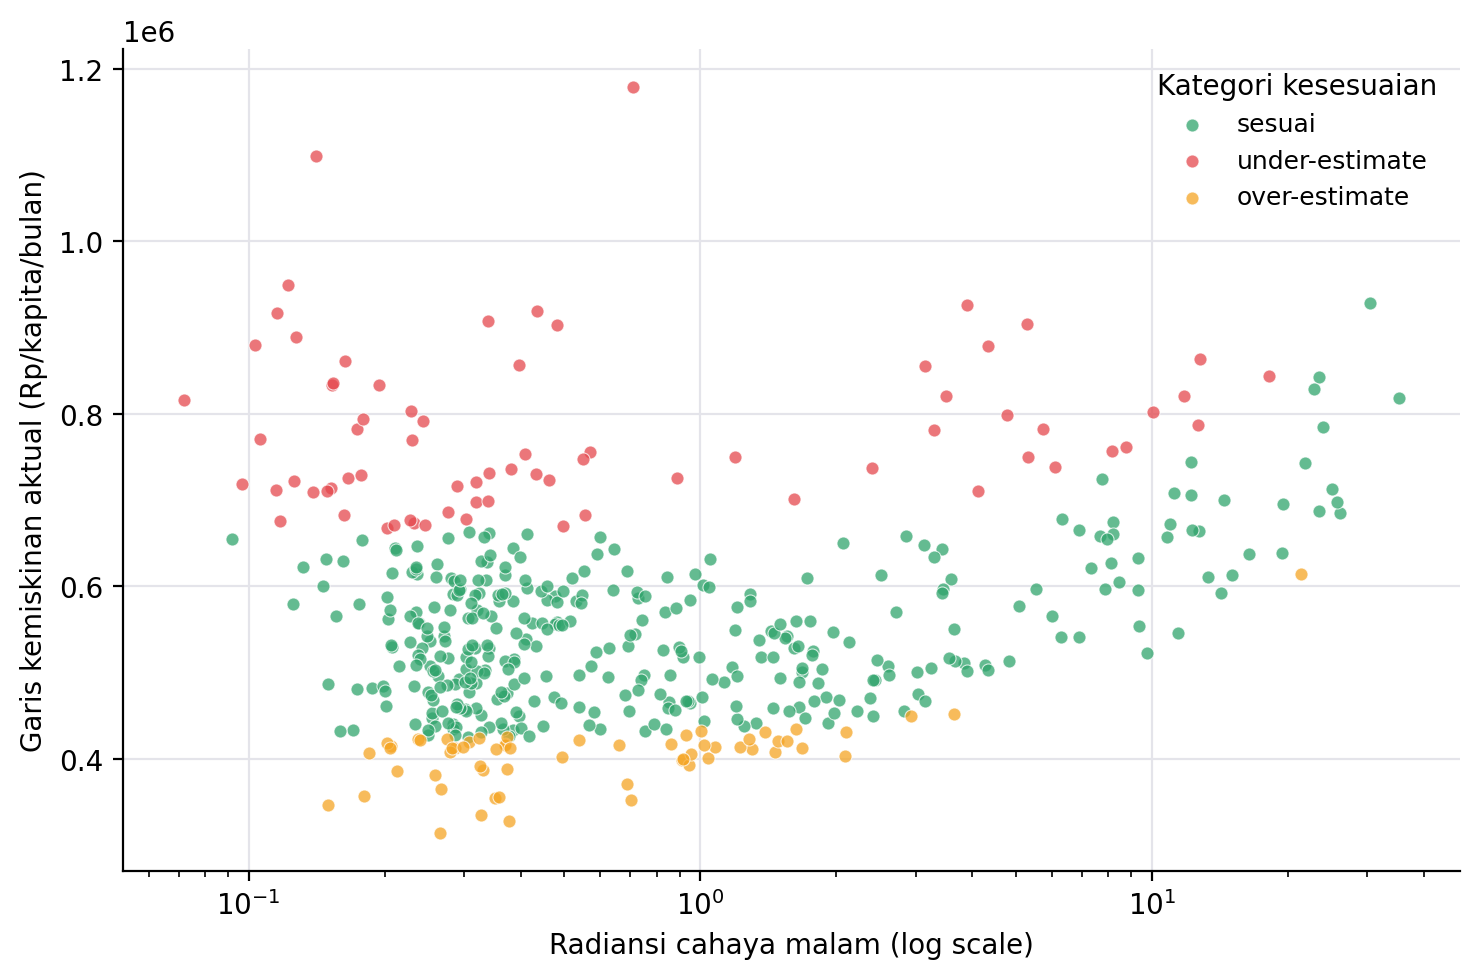

In [52]:
import matplotlib.pyplot as plt

WARNA = {'sesuai': '#30a46c', 'under_estimate': '#e5484d', 'over_estimate': '#f5a524'}

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=200)
for kategori, warna in WARNA.items():
    sub = donor[donor['kategori_mismatch'] == kategori]
    ax.scatter(sub['nightlight_mean'], sub['garis_kemiskinan'], c=warna, s=22,
               alpha=0.75, edgecolors='white', linewidths=0.4, label=kategori.replace('_', '-'), zorder=3)

ax.set_xscale('log')
ax.set_xlabel('Radiansi cahaya malam (log scale)', fontsize=10)
ax.set_ylabel('Garis kemiskinan aktual (Rp/kapita/bulan)', fontsize=10)
ax.legend(title='Kategori kesesuaian', fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, color='#e4e4ea', zorder=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/gambar2_sebaran_nightlight_kemiskinan.png', bbox_inches='tight')
print('tersimpan')

tersimpan


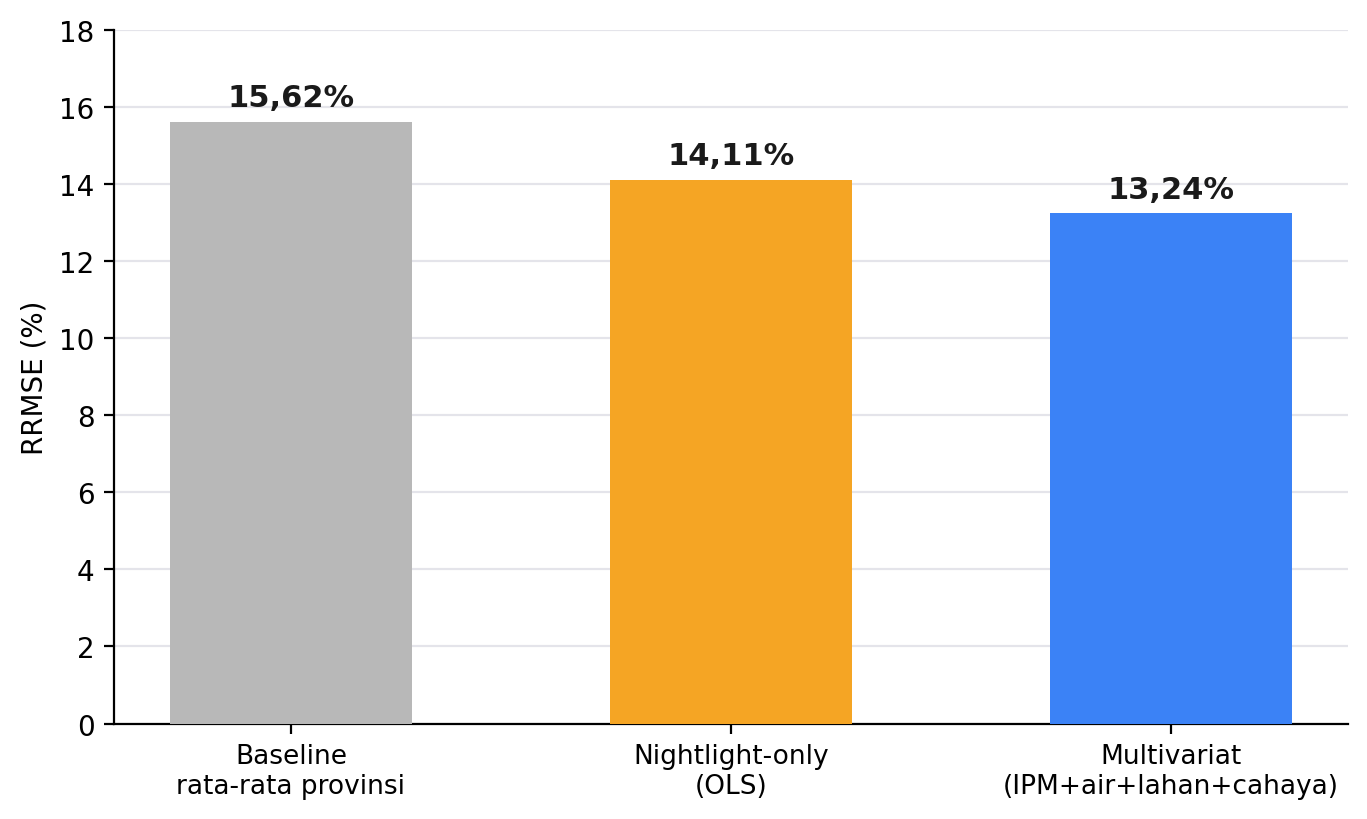

In [53]:
import matplotlib.pyplot as plt

labels = ['Baseline\nrata-rata provinsi', 'Nightlight-only\n(OLS)', 'Multivariat\n(IPM+air+lahan+cahaya)']
values = [15.62, 14.11, 13.24]
colors = ['#b8b8b8', '#f5a524', '#3b82f6']

fig, ax = plt.subplots(figsize=(7, 4.2), dpi=200)
bars = ax.bar(labels, values, color=colors, width=0.55, zorder=3)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.25, f'{v:.2f}%'.replace('.', ','),
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1a1a1a')

ax.set_ylabel('RRMSE (%)', fontsize=10)
ax.set_ylim(0, 18)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#e4e4ea', zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis='x', labelsize=9.5)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/gambar1_perbandingan_rrmse.png', bbox_inches='tight')
print('tersimpan')